# So sánh ba phương pháp — và chốt dùng cái nào

> Ba notebook trước mỗi cái đi sâu một phương pháp. File này đặt chúng cạnh nhau.

---

## Câu hỏi cần trả lời

| # | Câu hỏi | Phần |
|---|---|---|
| 1 | Ở mức 90%, phương pháp nào cho khoảng hẹp nhất mà vẫn đạt coverage? | 1 |
| 2 | Bức tranh có đổi khi hạ xuống 80% hay 70% không? | 2 |
| 3 | Coverage **điều kiện** — phương pháp nào đều nhất giữa các nhóm? | 3 |
| 4 | Chốt lại dùng gì | 4 |

**Câu 3 quan trọng hơn câu 1.** Coverage tổng thể đẹp mà một nhóm khách bị hụt 7 điểm thì con số
tổng thể đang che mất vấn đề — đúng điều mentor phê bình.

---

# 1. Ba phương pháp ở mức 90%

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90
print(f"Muc tin cay muc tieu: {MUC*100:.0f}%")

Muc tin cay muc tieu: 90%


## 1. Nạp dữ liệu — dự đoán điểm (Hybrid) và dự đoán phân vị (QR)

In [2]:
# --- Du doan diem tu Hybrid (cho phuong phap A) ---
cal_h = pd.read_parquet("../evaluation/uq_pred_calibration.parquet")
tes_h = pd.read_parquet("../evaluation/uq_pred_test.parquet")

# --- Du doan phan vi tu Quantile Regression (cho B va C) ---
cal_q = pd.read_parquet("../evaluation/qr_pred_calibration.parquet")
tes_q = pd.read_parquet("../evaluation/qr_pred_test.parquet")

assert len(cal_h) == len(cal_q) and len(tes_h) == len(tes_q)
assert np.allclose(cal_h.gia_that.values, cal_q.gia_that.values), "Lech calibration"
assert np.allclose(tes_h.gia_that.values, tes_q.gia_that.values), "Lech test"
print("Can hang: OK")

cal = cal_q.copy(); cal["hybrid_pred"] = cal_h.hybrid_pred.values
tes = tes_q.copy(); tes["hybrid_pred"] = tes_h.hybrid_pred.values

print(f"\nCALIBRATION: {len(cal):,} dong")
print(f"TEST       : {len(tes):,} dong")
print(f"\nMAE cua P50 (QR)     : {np.abs(tes.q50 - tes.gia_that).mean():,.0f}d")
print(f"MAE cua Hybrid       : {np.abs(tes.hybrid_pred - tes.gia_that).mean():,.0f}d")

Can hang: OK

CALIBRATION: 615,908 dong
TEST       : 864,360 dong

MAE cua P50 (QR)     : 18,829d
MAE cua Hybrid       : 18,048d


## 2. Phương pháp A — Conformal chuẩn hoá (nhắc lại từ notebook 01)

In [3]:
sai_so_rel = np.abs(cal.hybrid_pred - cal.gia_that) / cal.hybrid_pred
q_rel = np.quantile(sai_so_rel, MUC)

tes["A_low"]  = tes.hybrid_pred * (1 - q_rel)
tes["A_high"] = tes.hybrid_pred * (1 + q_rel)

print(f"PP A — Conformal chuan hoa")
print(f"  Nguong: +/-{q_rel*100:.2f}%")

PP A — Conformal chuan hoa
  Nguong: +/-30.09%


## 3. Phương pháp B — Quantile Regression thô

Dùng thẳng `[P05, P95]` do model dự đoán, **không hiệu chỉnh**.

In [4]:
tes["B_low"]  = tes.q05
tes["B_high"] = tes.q95

phu_cal = ((cal.gia_that >= cal.q05) & (cal.gia_that <= cal.q95)).mean()
phu_tes = ((tes.gia_that >= tes.q05) & (tes.gia_that <= tes.q95)).mean()
print(f"PP B — Quantile Regression tho")
print(f"  Coverage tren CALIBRATION : {phu_cal*100:.2f}%")
print(f"  Coverage tren TEST        : {phu_tes*100:.2f}%   (muc tieu {MUC*100:.0f}%)")
print(f"  -> Lech {abs(phu_tes-MUC)*100:.2f} diem % — QR KHONG bao dam ty le phu")

PP B — Quantile Regression tho
  Coverage tren CALIBRATION : 89.53%
  Coverage tren TEST        : 89.09%   (muc tieu 90%)
  -> Lech 0.91 diem % — QR KHONG bao dam ty le phu


## 4. ⭐ Phương pháp C — CQR (Conformalized Quantile Regression)

**Ý tưởng:** lấy khoảng của QR, rồi **nới ra hoặc thu vào** một lượng đúng bằng mức cần thiết để
đạt 90%, đo trên tập calibration.

**Điểm số bất tuân (conformity score):**

$$E_i = \max\big(\underbrace{q_{05}^{(i)} - y_i}_{\text{hụt dưới}},\ \underbrace{y_i - q_{95}^{(i)}}_{\text{vượt trên}}\big)$$

- $E_i < 0$ → giá thật **nằm trong** khoảng (còn dư chỗ)
- $E_i > 0$ → giá thật **nằm ngoài**, lệch ra bấy nhiêu

Lấy phân vị 90% của $E$ rồi cộng vào 2 đầu khoảng.

In [5]:
# --- Diem bat tuan tren CALIBRATION ---
E = np.maximum(cal.q05 - cal.gia_that, cal.gia_that - cal.q95)
n = len(cal)
# hieu chinh huu han mau: dung phan vi ceil((n+1)*muc)/n
k = int(np.ceil((n + 1) * MUC))
k = min(k, n)
q_cqr = np.sort(E.values)[k - 1]

tes["C_low"]  = tes.q05 - q_cqr
tes["C_high"] = tes.q95 + q_cqr

print(f"PP C — CQR")
print(f"  Diem bat tuan E: min {E.min():,.0f} | median {E.median():,.0f} | max {E.max():,.0f}")
print(f"  Nguong hieu chinh q = {q_cqr:,.0f}d")
if q_cqr > 0:
    print(f"  -> NOI RONG khoang QR them {q_cqr:,.0f}d moi ben")
else:
    print(f"  -> THU HEP khoang QR di {abs(q_cqr):,.0f}d moi ben")

PP C — CQR
  Diem bat tuan E: min -154,159 | median -18,660 | max 379,314
  Nguong hieu chinh q = 333d
  -> NOI RONG khoang QR them 333d moi ben


## 5. So sánh 3 phương pháp trên TEST

In [6]:
def danh_gia(lo, hi, ten):
    phu = ((tes.gia_that >= lo) & (tes.gia_that <= hi)).mean()
    rong = (hi - lo)
    return {"Phuong phap": ten,
            "Coverage (%)": phu * 100,
            "Do rong TB (d)": rong.mean(),
            "Do rong trung vi (d)": rong.median(),
            "Do rong / gia (%)": (rong / tes.gia_that).mean() * 100}

kq = pd.DataFrame([
    danh_gia(tes.A_low, tes.A_high, "A. Conformal chuan hoa"),
    danh_gia(tes.B_low, tes.B_high, "B. Quantile Regression"),
    danh_gia(tes.C_low, tes.C_high, "C. CQR"),
])
kq["Lech vs 90%"] = (kq["Coverage (%)"] - MUC*100).round(2)
display(kq.round(1))

dat = kq[np.abs(kq["Lech vs 90%"]) < 1.0]
if len(dat):
    tot = dat.loc[dat["Do rong TB (d)"].idxmin()]
    print(f">>> Dat coverage VA hep nhat: {tot['Phuong phap']} "
          f"({tot['Coverage (%)']:.2f}%, rong {tot['Do rong TB (d)']:,.0f}d)")

,Phuong phap,Coverage (%),Do rong TB (d),Do rong trung vi (d),Do rong / gia (%),Lech vs 90%
0,A. Conformal chuan hoa,89.6,72629.8,69408.5,61.1,-0.4
1,B. Quantile Regression,89.1,75782.9,73465.4,63.4,-0.9
2,C. CQR,89.5,76448.9,74131.4,64.0,-0.5


>>> Dat coverage VA hep nhat: A. Conformal chuan hoa (89.55%, rong 72,630d)


## 6. Conditional coverage — kiểm tra theo từng nhóm

In [7]:
tes["dai_km"] = pd.cut(tes.quang_duong, [0, 3, 5, 7, 10, 100],
                       labels=["<3km", "3-5km", "5-7km", "7-10km", ">10km"])
tes["mua"] = tes.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])

def khung(h):
    if h < 5:  return "0. Dem khuya"
    if h < 7:  return "1. Sang som"
    if h < 9:  return "2. Cao diem sang"
    if h < 16: return "3. Giua ngay"
    if h < 19: return "4. Cao diem chieu"
    return "5. Toi"
tes["khung"] = tes.gio_vn.apply(khung)


def cov_theo(cot, ten):
    rows = []
    for nhom, s in tes.groupby(cot, observed=True):
        r = {"Nhom": str(nhom), "n": len(s)}
        for k_ in ["A", "B", "C"]:
            r[k_] = ((s.gia_that >= s[f"{k_}_low"]) & (s.gia_that <= s[f"{k_}_high"])).mean() * 100
        rows.append(r)
    df = pd.DataFrame(rows)
    print(f"\nCOVERAGE THEO {ten.upper()}  (muc tieu {MUC*100:.0f}%)")
    display(df.round(2))
    return df

c_dai = cov_theo("dai_km", "dai quang duong")
c_gio = cov_theo("khung", "khung gio")
c_lag = cov_theo("requested_lag_minutes", "do tre quan sat")

print("\n" + "=" * 60)
print("DO LECH LON NHAT so voi 90% (cang nho cang tot)")
print("=" * 60)
for ten, df in [("Dai quang duong", c_dai), ("Khung gio", c_gio), ("Do tre lag", c_lag)]:
    print(f"  {ten:18s}", end="")
    for k_ in ["A", "B", "C"]:
        print(f"  {k_}: {np.abs(df[k_] - MUC*100).max():5.2f}", end="")
    print()


COVERAGE THEO DAI QUANG DUONG  (muc tieu 90%)

,Nhom,n,A,B,C
0,<3km,57968,94.17,87.45,89.42
1,3-5km,82664,89.61,89.02,89.52
2,5-7km,397492,89.24,89.37,89.75
3,7-10km,286408,89.16,89.15,89.41
4,>10km,39828,88.67,88.39,88.71



COVERAGE THEO KHUNG GIO  (muc tieu 90%)


,Nhom,n,A,B,C
0,0. Dem khuya,137584,89.88,88.89,89.76
1,1. Sang som,76892,89.72,89.31,89.81
2,2. Cao diem sang,77112,89.85,89.50,89.86
3,3. Giua ngay,266720,89.64,89.35,89.71
4,4. Cao diem chieu,114488,89.11,88.49,88.84
5,5. Toi,191564,89.29,88.98,89.34



COVERAGE THEO DO TRE QUAN SAT  (muc tieu 90%)


,Nhom,n,A,B,C
0,5,216090,89.82,89.22,89.67
1,10,216090,89.70,89.12,89.58
2,15,216090,89.56,89.03,89.48
3,30,216090,89.14,89.00,89.44



DO LECH LON NHAT so voi 90% (cang nho cang tot)
  Dai quang duong     A:  4.17  B:  2.55  C:  1.29
  Khung gio           A:  0.89  B:  1.51  C:  1.16
  Do tre lag          A:  0.86  B:  1.00  C:  0.56


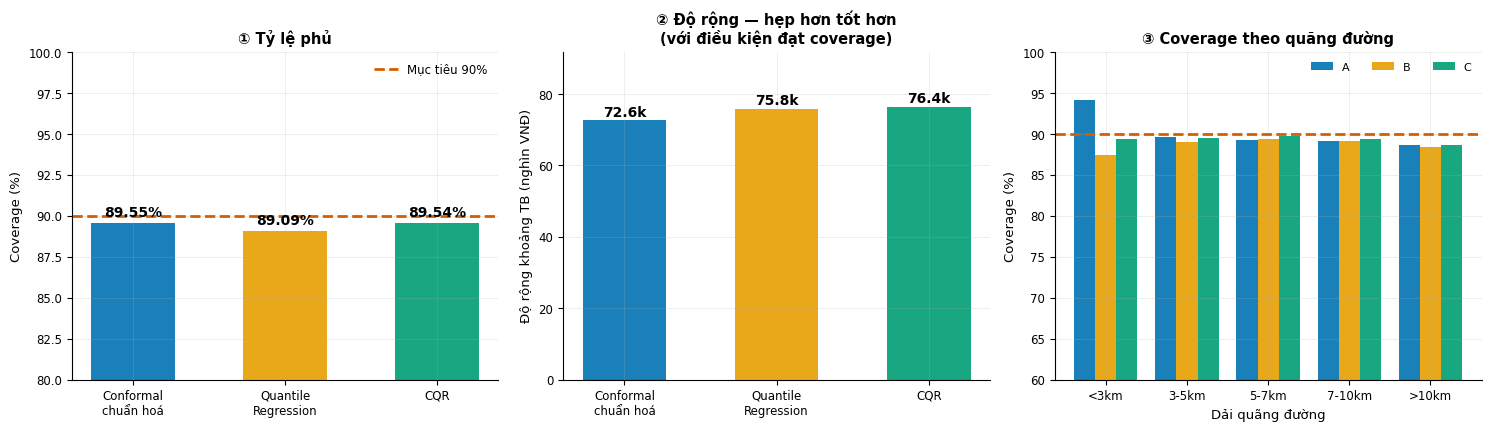

In [8]:
# ═════════ HINH UQ3 — so sanh 3 phuong phap ═════════
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
TEN = ["Conformal\nchuẩn hoá", "Quantile\nRegression", "CQR"]
MAU = [BLUE, ORANGE, GREEN]

cov = kq["Coverage (%)"].values
b_ = ax[0].bar(range(3), cov, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b_, cov):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+0.4, f"{v:.2f}%", ha="center",
               fontsize=10, fontweight="bold")
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label="Mục tiêu 90%")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(TEN, fontsize=8.5)
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(80, 100)
ax[0].set_title("① Tỷ lệ phủ", fontweight="bold"); ax[0].legend(frameon=False)

rong = kq["Do rong TB (d)"].values / 1000
b2 = ax[1].bar(range(3), rong, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b2, rong):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+1.2, f"{v:.1f}k", ha="center",
               fontsize=10, fontweight="bold")
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(TEN, fontsize=8.5)
ax[1].set_ylabel("Độ rộng khoảng TB (nghìn VNĐ)")
ax[1].set_title("② Độ rộng — hẹp hơn tốt hơn\n(với điều kiện đạt coverage)", fontweight="bold")
ax[1].set_ylim(0, max(rong)*1.2)

x = np.arange(len(c_dai)); w = 0.26
for i, (col, k_) in enumerate(zip(MAU, ["A", "B", "C"])):
    ax[2].bar(x + (i-1)*w, c_dai[k_], w, color=col, alpha=0.9, label=k_)
ax[2].axhline(MUC*100, color=RED, lw=2, ls="--")
ax[2].set_xticks(x); ax[2].set_xticklabels(c_dai.Nhom, fontsize=8.5)
ax[2].set_xlabel("Dải quãng đường"); ax[2].set_ylabel("Coverage (%)")
ax[2].set_title("③ Coverage theo quãng đường", fontweight="bold")
ax[2].set_ylim(60, 100); ax[2].legend(frameon=False, ncol=3, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "UQ3_so_sanh_3pp.png"); plt.show()

## 7. ⭐ Khoảng có **thích ứng** theo độ khó không?

Đây là ưu điểm chính QR/CQR hứa hẹn: khoảng **hẹp ở chuyến dễ**, **rộng ở chuyến khó**.

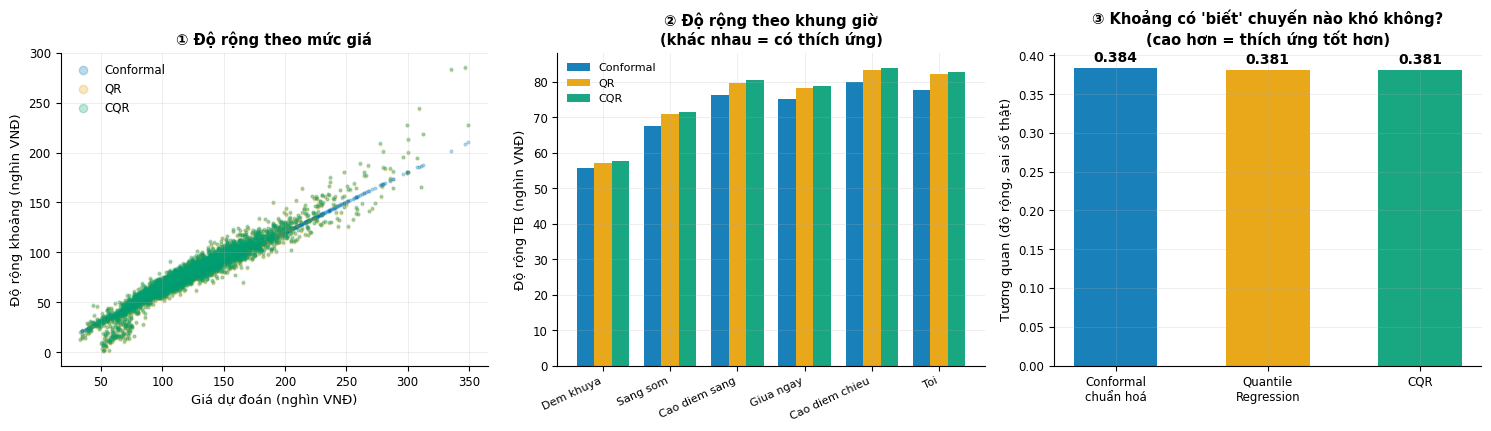

,PP,corr
0,Conformal,0.3841
1,QR,0.3809
2,CQR,0.3809


In [9]:
tes["A_rong"] = tes.A_high - tes.A_low
tes["B_rong"] = tes.B_high - tes.B_low
tes["C_rong"] = tes.C_high - tes.C_low
tes["sai_so"] = np.abs(tes.hybrid_pred - tes.gia_that)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) Do rong vs gia du doan
s = tes.sample(5000, random_state=1)
for k_, col, ten in zip(["A", "B", "C"], MAU, ["Conformal", "QR", "CQR"]):
    ax[0].scatter(s.hybrid_pred/1000, s[f"{k_}_rong"]/1000, s=4, alpha=0.25, color=col, label=ten)
ax[0].set_xlabel("Giá dự đoán (nghìn VNĐ)"); ax[0].set_ylabel("Độ rộng khoảng (nghìn VNĐ)")
ax[0].set_title("① Độ rộng theo mức giá", fontweight="bold")
ax[0].legend(frameon=False, markerscale=3)

# (b) Do rong theo khung gio
gg = tes.groupby("khung")
xk = np.arange(len(gg))
for i, (k_, col) in enumerate(zip(["A", "B", "C"], MAU)):
    ax[1].bar(xk + (i-1)*0.26, gg[f"{k_}_rong"].mean()/1000, 0.26, color=col, alpha=0.9,
              label=["Conformal", "QR", "CQR"][i])
ax[1].set_xticks(xk)
ax[1].set_xticklabels([k.split(". ")[1] for k in gg.groups.keys()], rotation=25, ha="right", fontsize=8)
ax[1].set_ylabel("Độ rộng TB (nghìn VNĐ)")
ax[1].set_title("② Độ rộng theo khung giờ\n(khác nhau = có thích ứng)", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

# (c) Tuong quan do rong vs sai so thuc te
rows = []
for k_ in ["A", "B", "C"]:
    rows.append({"PP": ["Conformal", "QR", "CQR"][["A","B","C"].index(k_)],
                 "corr": np.corrcoef(tes[f"{k_}_rong"], tes.sai_so)[0, 1]})
cr = pd.DataFrame(rows)
b3 = ax[2].bar(range(3), cr["corr"], color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b3, cr["corr"]):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+0.008, f"{v:.3f}", ha="center",
               fontsize=10, fontweight="bold")
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(TEN, fontsize=8.5)
ax[2].set_ylabel("Tương quan (độ rộng, sai số thật)")
ax[2].set_title("③ Khoảng có 'biết' chuyến nào khó không?\n(cao hơn = thích ứng tốt hơn)",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH / "UQ4_thich_ung.png"); plt.show()
display(cr.round(4))

## 8. Kết luận

In [10]:
print("=" * 68)
print("TONG KET UNCERTAINTY QUANTIFICATION")
print("=" * 68)
for _, r in kq.iterrows():
    print(f"  {r['Phuong phap']:26s} coverage {r['Coverage (%)']:6.2f}%  "
          f"| rong {r['Do rong TB (d)']:>9,.0f}d")
print()
print("Do lech lon nhat theo nhom:")
for ten, df in [("Dai quang duong", c_dai), ("Khung gio", c_gio), ("Do tre", c_lag)]:
    print(f"  {ten:18s}", end="")
    for k_ in ["A", "B", "C"]:
        print(f"  {k_}: {np.abs(df[k_] - MUC*100).max():5.2f}", end="")
    print()
print()
print("Thich ung theo do kho (tuong quan do rong vs sai so):")
for _, r in cr.iterrows():
    print(f"  {r['PP']:12s} {r['corr']:.4f}")

TONG KET UNCERTAINTY QUANTIFICATION
  A. Conformal chuan hoa     coverage  89.55%  | rong    72,630d
  B. Quantile Regression     coverage  89.09%  | rong    75,783d
  C. CQR                     coverage  89.54%  | rong    76,449d

Do lech lon nhat theo nhom:
  Dai quang duong     A:  4.17  B:  2.55  C:  1.29
  Khung gio           A:  0.89  B:  1.51  C:  1.16
  Do tre              A:  0.86  B:  1.00  C:  0.56

Thich ung theo do kho (tuong quan do rong vs sai so):
  Conformal    0.3841
  QR           0.3809
  CQR          0.3809


---

# 2. Ba phương pháp × ba mức tin cậy — trên tổng thể

In [11]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUCS = [0.70, 0.80, 0.90]
MAU_MUC = {0.70: PURPLE, 0.80: ORANGE, 0.90: BLUE}
PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
PP = ["Conformal chuẩn hoá", "QR thô", "CQR"]

f_cal = EVAL / "qr_pred_da_muc_calibration.parquet"
assert f_cal.exists(), "Thieu qr_pred_da_muc_*.parquet -> chay train/06 truoc!"
qc = pd.read_parquet(f_cal)
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")

assert np.allclose(qt.gia_that.values, ut.gia_that.values), "qr va uq khong khop hang!"
assert np.allclose(qc.gia_that.values, uc.gia_that.values), "calibration khong khop hang!"
print(f"Calibration {len(qc):,} | Test {len(qt):,} — khop hang.")
print(f"Phan vi co san: {[c for c in qt.columns if c.startswith('q')]}")

Calibration 615,908 | Test 864,360 — khop hang.
Phan vi co san: ['quang_duong', 'q05', 'q10', 'q15', 'q50', 'q85', 'q90', 'q95']


## 1. Dựng 9 cấu hình

In [12]:
sai_cal = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
KQ = {}


def them(pp, muc, lo, hi, ghi_chu=""):
    trong = (qt.gia_that.values >= lo) & (qt.gia_that.values <= hi)
    KQ[(pp, muc)] = dict(lo=lo, hi=hi, trong=trong, cov=trong.mean(),
                         rong=float(np.mean(hi - lo)), ghi_chu=ghi_chu)


for muc in MUCS:
    lo_c, hi_c = PV[muc]

    # --- A. Conformal chuan hoa ---
    q = np.quantile(sai_cal, muc)
    them("Conformal chuẩn hoá", muc,
         ut.hybrid_pred.values*(1-q), ut.hybrid_pred.values*(1+q), f"q = ±{q:.2%}")

    # --- B. QR tho ---
    them("QR thô", muc, qt[lo_c].values, qt[hi_c].values, f"{lo_c}–{hi_c}")

    # --- C. CQR ---
    E = np.maximum(qc[lo_c].values - qc.gia_that.values,
                   qc.gia_that.values - qc[hi_c].values)
    k = min(int(np.ceil((len(qc)+1)*muc)), len(qc))
    q_cqr = np.sort(E)[k-1]
    them("CQR", muc, qt[lo_c].values - q_cqr, qt[hi_c].values + q_cqr,
         f"q_cqr = {q_cqr:+,.0f}đ")

rows = []
for pp in PP:
    for muc in MUCS:
        r = KQ[(pp, muc)]
        rows.append({"Phương pháp": pp, "Mức": f"{muc:.0%}",
                     "Tham số": r["ghi_chu"],
                     "Coverage đạt": f"{r['cov']:.2%}",
                     "Lệch (điểm)": round((r["cov"]-muc)*100, 2),
                     "Độ rộng TB (đ)": round(r["rong"])})
B = pd.DataFrame(rows)
display(B)

print("\nDO RONG TB (d) — luoi 3x3:")
display(B.pivot(index="Phương pháp", columns="Mức",
                values="Độ rộng TB (đ)").reindex(PP))
print("LECH COVERAGE so voi danh muc (diem %):")
display(B.pivot(index="Phương pháp", columns="Mức",
                values="Lệch (điểm)").reindex(PP))

,Phương pháp,Mức,Tham số,Coverage đạt,Lệch (điểm),Độ rộng TB (đ)
0,Conformal chuẩn hoá,70%,q = ±18.78%,69.73%,-0.27,45320
1,Conformal chuẩn hoá,80%,q = ±23.25%,79.60%,-0.40,56118
2,Conformal chuẩn hoá,90%,q = ±30.09%,89.55%,-0.45,72630
3,QR thô,70%,q15–q85,68.88%,-1.12,47406
4,QR thô,80%,q10–q90,78.89%,-1.11,58772
5,QR thô,90%,q05–q95,89.09%,-0.91,75783
6,CQR,70%,q_cqr = +139đ,69.26%,-0.74,47684
7,CQR,80%,q_cqr = +256đ,79.44%,-0.56,59284
8,CQR,90%,q_cqr = +333đ,89.54%,-0.46,76449



DO RONG TB (d) — luoi 3x3:


Mức,70%,80%,90%
Phương pháp,,,
Conformal chuẩn hoá,45320,56118,72630
QR thô,47406,58772,75783
CQR,47684,59284,76449


LECH COVERAGE so voi danh muc (diem %):


Mức,70%,80%,90%
Phương pháp,,,
Conformal chuẩn hoá,-0.27,-0.40,-0.45
QR thô,-1.12,-1.11,-0.91
CQR,-0.74,-0.56,-0.46


## 2. ⭐ Ba biểu đồ — mỗi phương pháp một biểu đồ, mỗi biểu đồ 3 mức tin cậy

Trục hoành là **giá dự đoán**, trục tung là **khoảng giá**. Ba dải lồng nhau ứng với 3 mức tin cậy.
Chấm đỏ là **giá thật rơi ngoài** khoảng 90%.

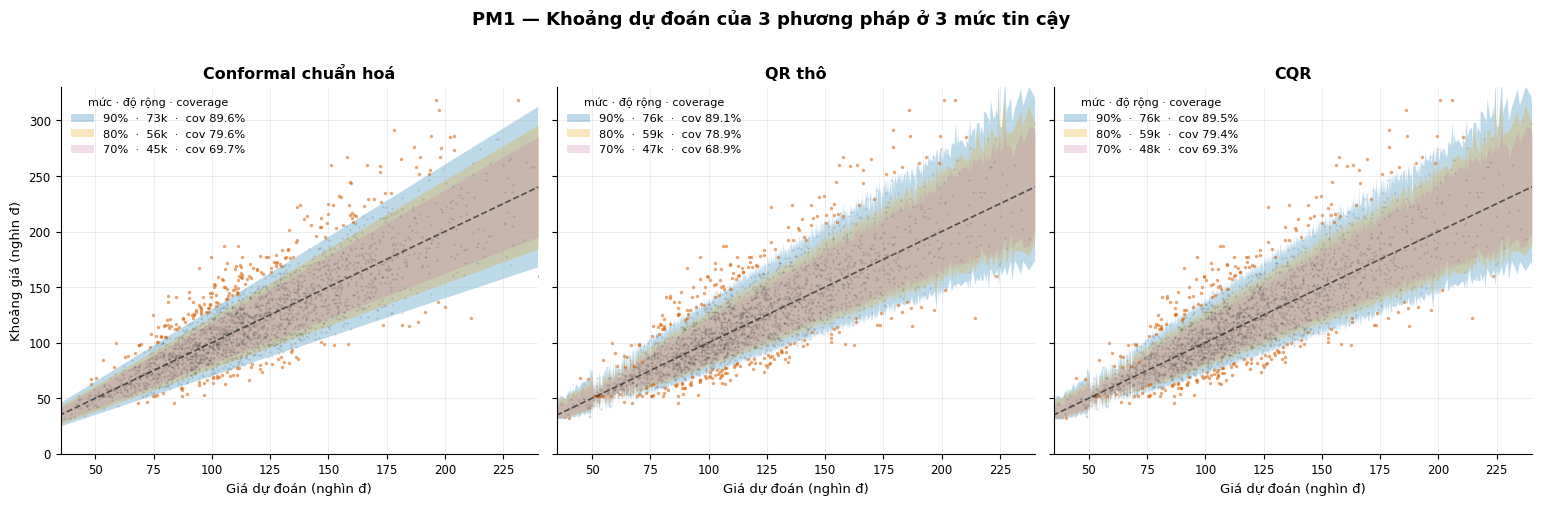

Doc hinh:
  · Dai cang rong = cang kem chac chan
  · Cham do = gia that roi NGOAI khoang 90%
  · Conformal: dai hinh NON (ty le voi gia) — do rong ty le cung mot he so
  · QR / CQR : dai bam theo do kho tung chuyen — khong ty le cung


In [13]:
# ═════════ HINH PM1 — 3 bieu do, moi cai 3 muc ═════════
rng = np.random.default_rng(11)
N_VE = 2500
idx = rng.choice(len(qt), N_VE, replace=False)
p_hat = ut.hybrid_pred.values[idx]
q50 = qt.q50.values[idx]
that = qt.gia_that.values[idx]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9), sharey=True)

for ax, pp in zip(axes, PP):
    # truc x = uoc luong diem cua chinh phuong phap do
    x = p_hat if pp == "Conformal chuẩn hoá" else q50
    o = np.argsort(x)
    xs = x[o]/1000

    for muc in sorted(MUCS, reverse=True):
        r = KQ[(pp, muc)]
        lo = np.asarray(r["lo"])[idx][o]/1000
        hi = np.asarray(r["hi"])[idx][o]/1000
        ax.fill_between(xs, lo, hi, color=MAU_MUC[muc], alpha=.26, lw=0,
                        label=f"{muc:.0%}  ·  {r['rong']/1000:.0f}k  ·  cov {r['cov']:.1%}")

    ngoai = ~KQ[(pp, 0.90)]["trong"][idx][o]
    ax.scatter(xs[~ngoai], that[o][~ngoai]/1000, s=2.5, color=INK, alpha=.16, lw=0)
    ax.scatter(xs[ngoai], that[o][ngoai]/1000, s=6, color=RED, alpha=.55, lw=0)
    ax.plot(xs, xs, color=INK, lw=1.2, ls="--", alpha=.7)

    ax.set_xlim(35, 240); ax.set_ylim(0, 330)
    ax.set_xlabel("Giá dự đoán (nghìn đ)")
    ax.legend(frameon=False, fontsize=8.2, loc="upper left", title="mức · độ rộng · coverage",
              title_fontsize=8)
    ax.set_title(pp, fontweight="bold", fontsize=11.5)

axes[0].set_ylabel("Khoảng giá (nghìn đ)")
fig.suptitle("PM1 — Khoảng dự đoán của 3 phương pháp ở 3 mức tin cậy",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "PM1_ba_pp_ba_muc.png"); plt.show()

print("Doc hinh:")
print("  · Dai cang rong = cang kem chac chan")
print("  · Cham do = gia that roi NGOAI khoang 90%")
print("  · Conformal: dai hinh NON (ty le voi gia) — do rong ty le cung mot he so")
print("  · QR / CQR : dai bam theo do kho tung chuyen — khong ty le cung")

## 3. Coverage đạt được so với danh mục

Đây là **ràng buộc bắt buộc**: coverage phải đạt danh mục. Chỉ khi đạt rồi mới so độ rộng.

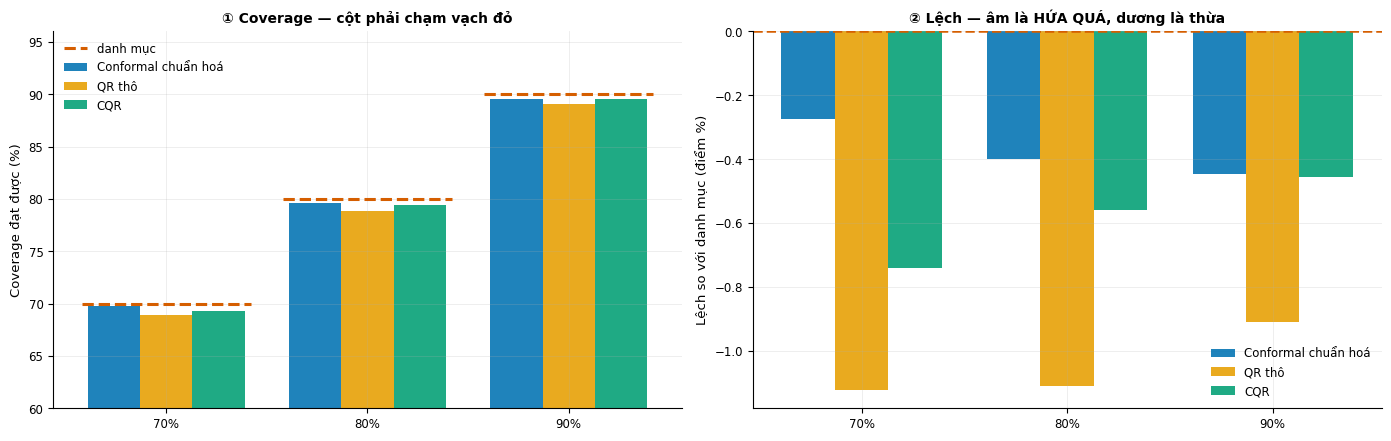

Lech coverage lon nhat cua tung phuong phap (diem %):
  Conformal chuẩn hoá    0.45
  QR thô                 1.12
  CQR                    0.74


In [14]:
# ═════════ HINH PM2 — coverage ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(3); w = .26
for i, pp in enumerate(PP):
    v = [KQ[(pp, m)]["cov"]*100 for m in MUCS]
    ax[0].bar(x + (i-1)*w, v, w, label=pp,
              color=[BLUE, ORANGE, GREEN][i], alpha=.88)
for j, m in enumerate(MUCS):
    ax[0].plot([j-.42, j+.42], [m*100, m*100], color=RED, lw=2.2, ls="--",
               zorder=5)
ax[0].plot([], [], color=RED, lw=2.2, ls="--", label="danh mục")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[0].set_ylabel("Coverage đạt được (%)"); ax[0].set_ylim(60, 96)
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage — cột phải chạm vạch đỏ", fontweight="bold", fontsize=10)

for i, pp in enumerate(PP):
    v = [(KQ[(pp, m)]["cov"]-m)*100 for m in MUCS]
    ax[1].bar(x + (i-1)*w, v, w, label=pp, color=[BLUE, ORANGE, GREEN][i], alpha=.88)
ax[1].axhline(0, color=RED, lw=1.8, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[1].set_ylabel("Lệch so với danh mục (điểm %)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Lệch — âm là HỨA QUÁ, dương là thừa", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "PM2_coverage.png"); plt.show()

le = B.pivot(index="Phương pháp", columns="Mức", values="Lệch (điểm)").reindex(PP)
print("Lech coverage lon nhat cua tung phuong phap (diem %):")
for pp in PP:
    print(f"  {pp:22s} {le.loc[pp].abs().max():.2f}")

## 4. Độ rộng — phương pháp nào hẹp nhất ở từng mức

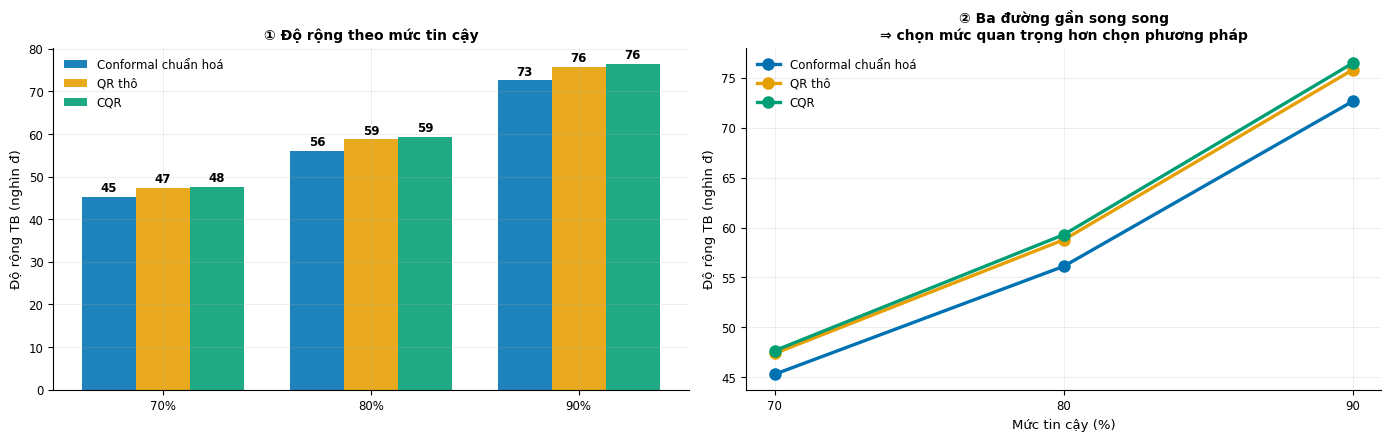

Hep nhat o tung muc:
  70%: Conformal chuẩn hoá       45,320d
  80%: Conformal chuẩn hoá       56,118d
  90%: Conformal chuẩn hoá       72,630d

Chenh do rong GIUA CAC PHUONG PHAP (trong cung 1 muc): 5.2%–5.6%
Chenh do rong GIUA CAC MUC (trong cung 1 phuong phap): ~60%
=> Chon MUC TIN CAY anh huong lon hon nhieu so voi chon PHUONG PHAP.


In [15]:
# ═════════ HINH PM3 — do rong ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

for i, pp in enumerate(PP):
    v = [KQ[(pp, m)]["rong"]/1000 for m in MUCS]
    ax[0].bar(x + (i-1)*w, v, w, label=pp, color=[BLUE, ORANGE, GREEN][i], alpha=.88)
    for j, vv in enumerate(v):
        ax[0].text(j+(i-1)*w, vv+1.2, f"{vv:.0f}", ha="center", fontsize=8.5,
                   fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[0].set_ylabel("Độ rộng TB (nghìn đ)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Độ rộng theo mức tin cậy", fontweight="bold", fontsize=10)

for i, pp in enumerate(PP):
    v = [KQ[(pp, m)]["rong"] for m in MUCS]
    ax[1].plot([m*100 for m in MUCS], np.array(v)/1000, marker="o", lw=2.4, ms=8,
               color=[BLUE, ORANGE, GREEN][i], label=pp)
ax[1].set_xlabel("Mức tin cậy (%)"); ax[1].set_ylabel("Độ rộng TB (nghìn đ)")
ax[1].set_xticks([m*100 for m in MUCS])
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Ba đường gần song song\n⇒ chọn mức quan trọng hơn chọn phương pháp",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "PM3_do_rong.png"); plt.show()

R = B.pivot(index="Phương pháp", columns="Mức", values="Độ rộng TB (đ)").reindex(PP)
print("Hep nhat o tung muc:")
for m in [f"{v:.0%}" for v in MUCS]:
    print(f"  {m}: {R[m].idxmin():22s} {R[m].min():>9,.0f}d")
print()
bien_pp = (R.max() / R.min() - 1) * 100
bien_muc = (R.loc[PP[0]].max() / R.loc[PP[0]].min() - 1) * 100
print(f"Chenh do rong GIUA CAC PHUONG PHAP (trong cung 1 muc): "
      f"{bien_pp.min():.1f}%–{bien_pp.max():.1f}%")
print(f"Chenh do rong GIUA CAC MUC (trong cung 1 phuong phap): ~{bien_muc:.0f}%")
print("=> Chon MUC TIN CAY anh huong lon hon nhieu so voi chon PHUONG PHAP.")

## 5. Coverage điều kiện của cả 9 cấu hình

Coverage tổng đạt danh mục chưa đủ. Ô nào **đỏ đậm** là cấu hình bất công giữa các nhóm.

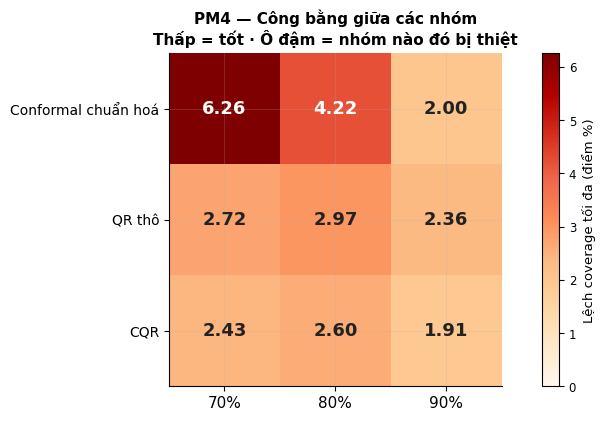

,Phương pháp,Mức,Giờ,Quãng đường,Thời tiết,XẤU NHẤT
0,Conformal chuẩn hoá,70%,1.08,6.26,0.38,6.26
1,Conformal chuẩn hoá,80%,1.29,4.22,0.48,4.22
2,Conformal chuẩn hoá,90%,1.33,2.00,0.50,2.00
3,QR thô,70%,2.72,2.07,1.27,2.72
4,QR thô,80%,2.97,2.01,1.27,2.97
5,QR thô,90%,2.36,1.93,1.03,2.36
6,CQR,70%,2.43,1.56,0.90,2.43
7,CQR,80%,2.60,1.29,0.74,2.60
8,CQR,90%,1.91,1.13,0.58,1.91



CONG BANG NHAT: CQR o muc 90%  (1.91 diem)
BAT CONG NHAT : Conformal chuẩn hoá o muc 70%  (6.26 diem)


In [16]:
# ═════════ HINH PM4 — coverage dieu kien ═════════
t = pd.DataFrame({"gio_vn": qt.gio_vn.values, "km": qt.quang_duong.values,
                  "mua": qt.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values})
t["nhom_km"] = pd.qcut(t.km, 8, labels=False, duplicates="drop")

M = np.zeros((len(PP), len(MUCS)))
CHI_TIET = []
for i, pp in enumerate(PP):
    for j, m in enumerate(MUCS):
        t["tr"] = KQ[(pp, m)]["trong"]
        lg = abs(t.groupby("gio_vn").tr.mean()*100 - m*100).max()
        lk = abs(t.groupby("nhom_km").tr.mean()*100 - m*100).max()
        lt = abs(t.groupby("mua").tr.mean()*100 - m*100).max()
        M[i, j] = max(lg, lk, lt)
        CHI_TIET.append({"Phương pháp": pp, "Mức": f"{m:.0%}",
                         "Giờ": round(lg, 2), "Quãng đường": round(lk, 2),
                         "Thời tiết": round(lt, 2), "XẤU NHẤT": round(M[i, j], 2)})

fig, ax = plt.subplots(figsize=(8.4, 4.3))
im = ax.imshow(M, cmap="OrRd", vmin=0, vmax=M.max())
ax.set_xticks(range(3)); ax.set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(PP, fontsize=10)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=13,
                fontweight="bold", color="white" if M[i, j] > M.max()*.6 else INK)
plt.colorbar(im, ax=ax, label="Lệch coverage tối đa (điểm %)")
ax.set_title("PM4 — Công bằng giữa các nhóm\nThấp = tốt · Ô đậm = nhóm nào đó bị thiệt",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "PM4_coverage_dieu_kien.png"); plt.show()

display(pd.DataFrame(CHI_TIET))
i_, j_ = np.unravel_index(np.argmin(M), M.shape)
print(f"\nCONG BANG NHAT: {PP[i_]} o muc {MUCS[j_]:.0%}  ({M[i_,j_]:.2f} diem)")
i_, j_ = np.unravel_index(np.argmax(M), M.shape)
print(f"BAT CONG NHAT : {PP[i_]} o muc {MUCS[j_]:.0%}  ({M[i_,j_]:.2f} diem)")

## Kết luận

In [17]:
print("╔" + "═"*74 + "╗")
print("║" + " BA PHUONG PHAP x BA MUC TIN CAY — TONG KET ".center(74) + "║")
print("╚" + "═"*74 + "╝")
print()
print(f"  {'':24s}" + "".join(f"{m:>16.0%}" for m in MUCS))
print("  " + "-"*72)
for pp in PP:
    print(f"  {pp:24s}" + "".join(
        f"{KQ[(pp,m)]['rong']:>14,.0f}d " for m in MUCS))
print()
print("  COVERAGE (lech so voi danh muc, diem %):")
for pp in PP:
    print(f"  {pp:24s}" + "".join(
        f"{(KQ[(pp,m)]['cov']-m)*100:>+15.2f} " for m in MUCS))
print()
print("  CONG BANG (lech coverage toi da giua nhom, diem %):")
for i, pp in enumerate(PP):
    print(f"  {pp:24s}" + "".join(f"{M[i,j]:>15.2f} " for j in range(3)))
print()
print("─"*76)
print("  RUT RA:")
print(f"    1. Chon MUC anh huong do rong ~{bien_muc:.0f}%, chon PHUONG PHAP chi ~"
      f"{bien_pp.max():.0f}% => uu tien chot MUC truoc.")
print("    2. QR tho khong co bao dam — coverage bam sat la MAY, khong phai dam bao.")
print("    3. Cang ha muc, cong bang giua nhom cang xau o CA BA phuong phap.")
print("─"*76)

╔══════════════════════════════════════════════════════════════════════════╗
║                BA PHUONG PHAP x BA MUC TIN CAY — TONG KET                ║
╚══════════════════════════════════════════════════════════════════════════╝

                                       70%             80%             90%
  ------------------------------------------------------------------------
  Conformal chuẩn hoá             45,320d         56,118d         72,630d 
  QR thô                          47,406d         58,772d         75,783d 
  CQR                             47,684d         59,284d         76,449d 

  COVERAGE (lech so voi danh muc, diem %):
  Conformal chuẩn hoá               -0.27           -0.40           -0.45 
  QR thô                            -1.12           -1.11           -0.91 
  CQR                               -0.74           -0.56           -0.46 

  CONG BANG (lech coverage toi da giua nhom, diem %):
  Conformal chuẩn hoá                6.26            4.22            

---

# 3. Ba phương pháp × ba mức — phân rã theo band giá

Đây là phần trả lời câu 3, và là chỗ kết luận của tuần 3 bị sửa lại.

In [18]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
MUC_PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
MUCS = [0.70, 0.80, 0.90]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qc = pd.read_parquet(EVAL / "qr_pred_da_muc_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")

# BAT BUOC: bon file phai cung thu tu hang thi moi gan band chung duoc
assert len(uc) == len(qc) and len(ut) == len(qt), "so dong lech"
assert np.allclose(uc.gia_that.values, qc.gia_that.values), "calibration lech hang"
assert np.allclose(ut.gia_that.values, qt.gia_that.values), "test lech hang"
print(f"Hang khop: calibration {len(uc):,} · test {len(ut):,}")

# Band dinh nghia bang MOT nguon duy nhat (gia du doan cua Hybrid),
# de ba phuong phap duoc so tren cung cach chia — khong ai duoc loi the.
for d, nguon in [(uc, uc), (ut, ut), (qc, uc), (qt, ut)]:
    d["band"] = pd.cut(nguon.hybrid_pred.values, CANH, labels=TEN, right=False)
print("\nSo chuyen tung band (tap test):")
print(ut.band.value_counts().reindex(TEN).to_string())

Hang khop: calibration 615,908 · test 864,360

So chuyen tung band (tap test):
band
<50k         10821
50–100k     264201
100–150k    409883
150–200k    149324
200–300k     28875
>300k         1256


## 1. Tính khoảng cho cả 9 tổ hợp

Ba phương pháp:

| Phương pháp | Cách dựng khoảng | Bảo đảm |
|---|---|---|
| **Conformal chuẩn hoá** | `q = phân vị(\|sai số\|/dự đoán)` trên calibration → `p̂ × (1 ± q)` | Hữu hạn mẫu |
| **QR thô** | Lấy thẳng 2 phân vị của model quantile | ❌ Không |
| **CQR** | Hiệu chỉnh 2 phân vị bằng conformity score trên calibration | Hữu hạn mẫu |

In [19]:
def khoang(muc):
    """Tra ve dict: ten phuong phap -> (can duoi, can tren) tren tap TEST."""
    lo_a, hi_a = MUC_PV[muc]
    out = {}

    # 1. Conformal chuan hoa
    e = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
    q = np.quantile(e, muc)
    out["Conformal"] = (ut.hybrid_pred*(1-q), ut.hybrid_pred*(1+q))

    # 2. QR tho — lay thang, khong hieu chinh
    out["QR thô"] = (qt[lo_a], qt[hi_a])

    # 3. CQR — hieu chinh bang conformity score
    E = np.maximum(qc[lo_a] - qc.gia_that, qc.gia_that - qc[hi_a]).values
    k = min(int(np.ceil((len(qc)+1)*muc)), len(qc))
    qq = np.sort(E)[k-1]
    out["CQR"] = (qt[lo_a] - qq, qt[hi_a] + qq)
    return out


def do_band(lo, hi, muc):
    """Bang chi tiet theo band cho 1 khoang."""
    d = pd.DataFrame({"band": ut.band.values, "y": ut.gia_that.values,
                      "p": ut.hybrid_pred.values,
                      "lo": np.asarray(lo), "hi": np.asarray(hi)})
    d["trong"] = (d.y >= d.lo) & (d.y <= d.hi)
    d["rong"] = d.hi - d.lo
    d["tren"] = d.y > d.hi          # that CAO hon can tren -> model hua thap
    d["duoi"] = d.y < d.lo
    g = d.groupby("band", observed=True).agg(
        n=("y", "size"), cvg=("trong", "mean"),
        rong_tb=("rong", "mean"), rong_td=("rong", "median"),
        p_tb=("p", "mean"), hut_tren=("tren", "mean"), hut_duoi=("duoi", "mean")
    ).reindex(TEN)
    g["lech"] = (g.cvg - muc) * 100
    g["rong_tuong_doi"] = g.rong_tb / g.p_tb
    return g


BANG = {}
for muc in MUCS:
    for ten_pp, (lo, hi) in khoang(muc).items():
        BANG[(ten_pp, muc)] = do_band(lo, hi, muc)

print(f"Da tinh {len(BANG)} to hop x 6 band = {len(BANG)*6} dong ket qua")

Da tinh 9 to hop x 6 band = 54 dong ket qua


## 2. Ma trận tổng — lệch coverage tối đa của từng ô

Một con số cho mỗi ô: **band nào lệch danh mục nhiều nhất, lệch bao nhiêu điểm**.
Đây là thước đo **coverage điều kiện** — coverage tổng thể có thể đẹp mà vẫn giấu một band tệ.

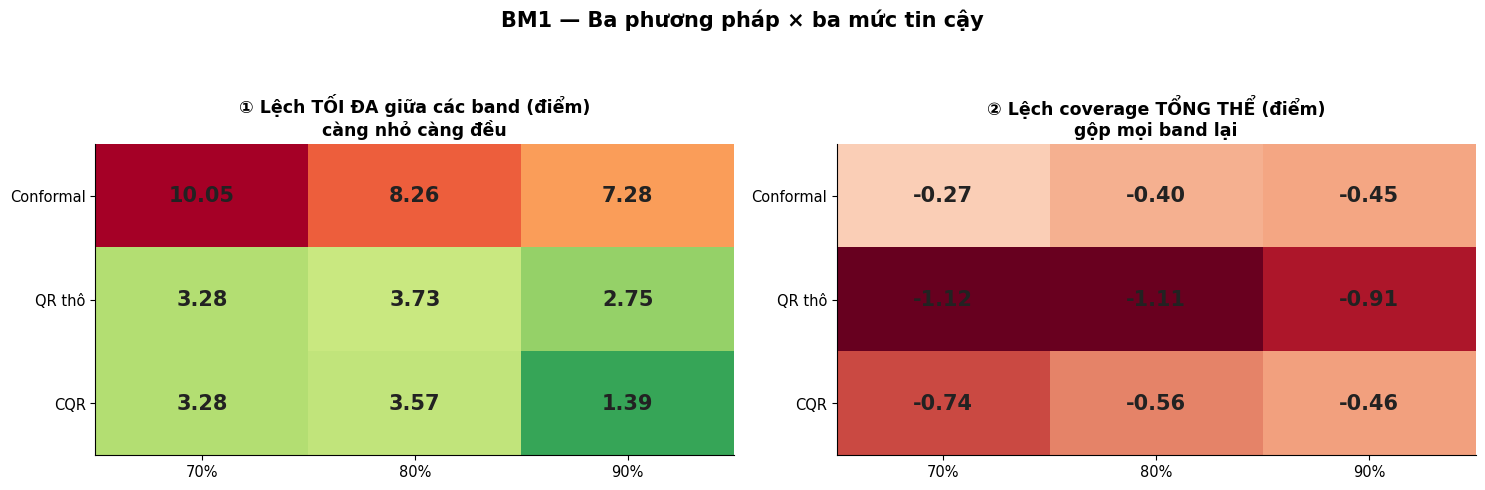

Phuong phap                   70%                80%                90%
------------------------------------------------------------------------
Conformal        tong -0.27 | max 10.05   tong -0.40 | max 8.26   tong -0.45 | max 7.28
QR thô           tong -1.12 | max 3.28   tong -1.11 | max 3.73   tong -0.91 | max 2.75
CQR              tong -0.74 | max 3.28   tong -0.56 | max 3.57   tong -0.46 | max 1.39

tong = lech coverage gop moi band · max = lech lon nhat cua mot band rieng le


In [20]:
# ═════════ HINH BM1 — ma tran 3 phuong phap x 3 muc ═════════
PP = ["Conformal", "QR thô", "CQR"]
M = np.zeros((len(PP), len(MUCS)))
TONG = np.zeros((len(PP), len(MUCS)))
for i, pp in enumerate(PP):
    for j, muc in enumerate(MUCS):
        g = BANG[(pp, muc)]
        M[i, j] = g.lech.abs().max()
        TONG[i, j] = (g.cvg * g.n).sum() / g.n.sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for a, dat, ten, fmt in [
        (ax[0], M, "① Lệch TỐI ĐA giữa các band (điểm)\ncàng nhỏ càng đều", "{:.2f}"),
        (ax[1], TONG - np.array(MUCS)*100,
         "② Lệch coverage TỔNG THỂ (điểm)\ngộp mọi band lại", "{:+.2f}")]:
    im = a.imshow(dat, cmap="RdYlGn_r" if ten.startswith("①") else "RdBu",
                  aspect="auto",
                  vmin=0 if ten.startswith("①") else -abs(dat).max(),
                  vmax=abs(dat).max())
    a.set_xticks(range(len(MUCS)))
    a.set_xticklabels([f"{m:.0%}" for m in MUCS])
    a.set_yticks(range(len(PP))); a.set_yticklabels(PP)
    for i in range(len(PP)):
        for j in range(len(MUCS)):
            a.text(j, i, fmt.format(dat[i, j]), ha="center", va="center",
                   fontsize=15, fontweight="bold", color=INK)
    a.set_title(ten, fontweight="bold", fontsize=12.5)
    a.grid(False)

fig.suptitle("BM1 — Ba phương pháp × ba mức tin cậy", fontweight="bold",
             fontsize=15, y=1.06)
plt.tight_layout(); plt.savefig(HINH / "BM1_ma_tran_3pp_3muc.png"); plt.show()

print(f"{'Phuong phap':14s} " + " ".join(f"{m:>18.0%}" for m in MUCS))
print("-" * 72)
for i, pp in enumerate(PP):
    print(f"{pp:14s} " + " ".join(
        f"  tong {TONG[i,j]-MUCS[j]*100:+5.2f} | max {M[i,j]:4.2f}" for j in range(len(MUCS))))
print()
print("tong = lech coverage gop moi band · max = lech lon nhat cua mot band rieng le")

## 3. Coverage theo band — nhìn thẳng vào chỗ hỏng

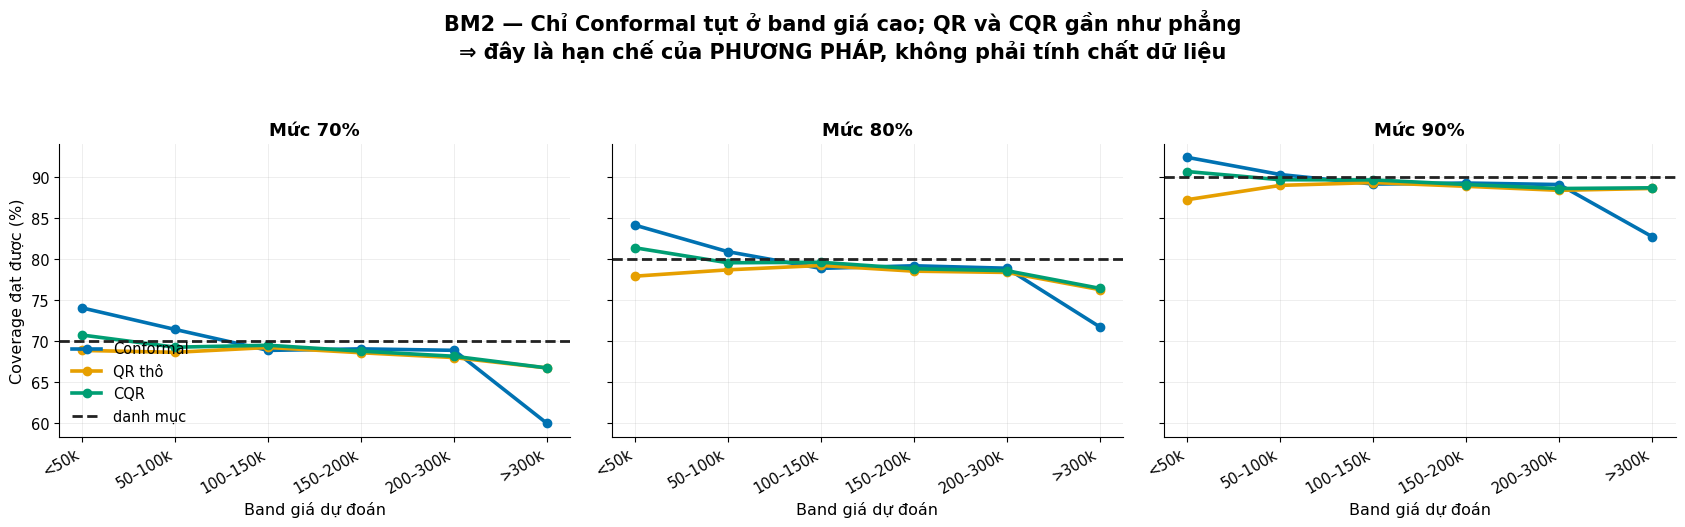

Coverage band THAP NHAT vs CAO NHAT o moi to hop:
  70% Conformal  : 59.95% (>300k) -> 74.04% (<50k)  | chenh 14.09 diem
  70% QR thô     : 66.72% (>300k) -> 69.22% (100–150k)  | chenh  2.50 diem
  70% CQR        : 66.72% (>300k) -> 70.73% (<50k)  | chenh  4.01 diem
  80% Conformal  : 71.74% (>300k) -> 84.14% (<50k)  | chenh 12.41 diem
  80% QR thô     : 76.27% (>300k) -> 79.22% (100–150k)  | chenh  2.95 diem
  80% CQR        : 76.43% (>300k) -> 81.38% (<50k)  | chenh  4.95 diem
  90% Conformal  : 82.72% (>300k) -> 92.40% (<50k)  | chenh  9.68 diem
  90% QR thô     : 87.25% (<50k) -> 89.34% (100–150k)  | chenh  2.09 diem
  90% CQR        : 88.61% (200–300k) -> 90.68% (<50k)  | chenh  2.07 diem


In [21]:
# ═════════ HINH BM2 — coverage theo band, 3 muc x 3 phuong phap ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
MAU_PP = {"Conformal": BLUE, "QR thô": ORANGE, "CQR": GREEN}
x = np.arange(len(TEN))

for a, muc in zip(ax, MUCS):
    for pp in PP:
        g = BANG[(pp, muc)]
        a.plot(x, g.cvg*100, lw=2.6, marker="o", ms=6, color=MAU_PP[pp], label=pp)
    a.axhline(muc*100, color=INK, lw=2, ls="--", label="danh mục")
    a.set_xticks(x); a.set_xticklabels(TEN, rotation=30, ha="right")
    a.set_title(f"Mức {muc:.0%}", fontweight="bold")
    a.set_xlabel("Band giá dự đoán")
ax[0].set_ylabel("Coverage đạt được (%)")
ax[0].legend(frameon=False, loc="lower left")

fig.suptitle("BM2 — Chỉ Conformal tụt ở band giá cao; QR và CQR gần như phẳng\n"
             "⇒ đây là hạn chế của PHƯƠNG PHÁP, không phải tính chất dữ liệu",
             fontweight="bold", fontsize=15, y=1.05)
plt.tight_layout(); plt.savefig(HINH / "BM2_coverage_theo_band.png"); plt.show()

print("Coverage band THAP NHAT vs CAO NHAT o moi to hop:")
for muc in MUCS:
    for pp in PP:
        g = BANG[(pp, muc)]
        print(f"  {muc:.0%} {pp:11s}: {g.cvg.min():.2%} ({g.cvg.idxmin()}) "
              f"-> {g.cvg.max():.2%} ({g.cvg.idxmax()})  | chenh "
              f"{(g.cvg.max()-g.cvg.min())*100:5.2f} diem")

## 4. Bảng chi tiết — mức 90%, cả ba phương pháp

Đây là bảng đem vào báo cáo. Ba cột cuối là chỗ mentor sẽ đọc kỹ:
**hụt trên** = giá thật cao hơn cận trên (model hứa thấp), **hụt dưới** = ngược lại.

In [22]:
def in_bang(muc):
    rows = []
    for pp in PP:
        g = BANG[(pp, muc)]
        for b in TEN:
            r = g.loc[b]
            rows.append({
                "Phương pháp": pp, "Band": b, "n": f"{int(r.n):,}",
                "Coverage": f"{r.cvg:.2%}", "Lệch (điểm)": f"{r.lech:+.2f}",
                "Rộng TB (đ)": f"{r.rong_tb:,.0f}",
                "Rộng/giá": f"{r.rong_tuong_doi:.1%}",
                "Hụt trên": f"{r.hut_tren:.2%}", "Hụt dưới": f"{r.hut_duoi:.2%}"})
    return pd.DataFrame(rows)


B90 = in_bang(0.90)
print("MUC 90% — BANG CHI TIET")
display(B90)

MUC 90% — BANG CHI TIET


,Phương pháp,Band,n,Coverage,Lệch (điểm),Rộng TB (đ),Rộng/giá,Hụt trên,Hụt dưới
0,Conformal,<50k,"10,821",92.40%,+2.40,"26,293",60.2%,7.07%,0.53%
1,Conformal,50–100k,"264,201",90.31%,+0.31,"49,412",60.2%,7.26%,2.43%
2,Conformal,100–150k,"409,883",89.15%,-0.85,"73,435",60.2%,8.09%,2.76%
3,Conformal,150–200k,"149,324",89.27%,-0.73,"101,753",60.2%,8.03%,2.69%
4,Conformal,200–300k,"28,875",89.09%,-0.91,"134,783",60.2%,8.44%,2.47%
5,Conformal,>300k,"1,256",82.72%,-7.28,"201,911",60.2%,11.78%,5.49%
6,QR thô,<50k,"10,821",87.25%,-2.75,"24,989",57.2%,4.25%,8.50%
7,QR thô,50–100k,"264,201",88.99%,-1.01,"50,424",61.4%,5.12%,5.90%
8,QR thô,100–150k,"409,883",89.34%,-0.66,"77,820",63.8%,5.77%,4.89%
9,QR thô,150–200k,"149,324",88.87%,-1.13,"105,257",62.3%,6.63%,4.50%


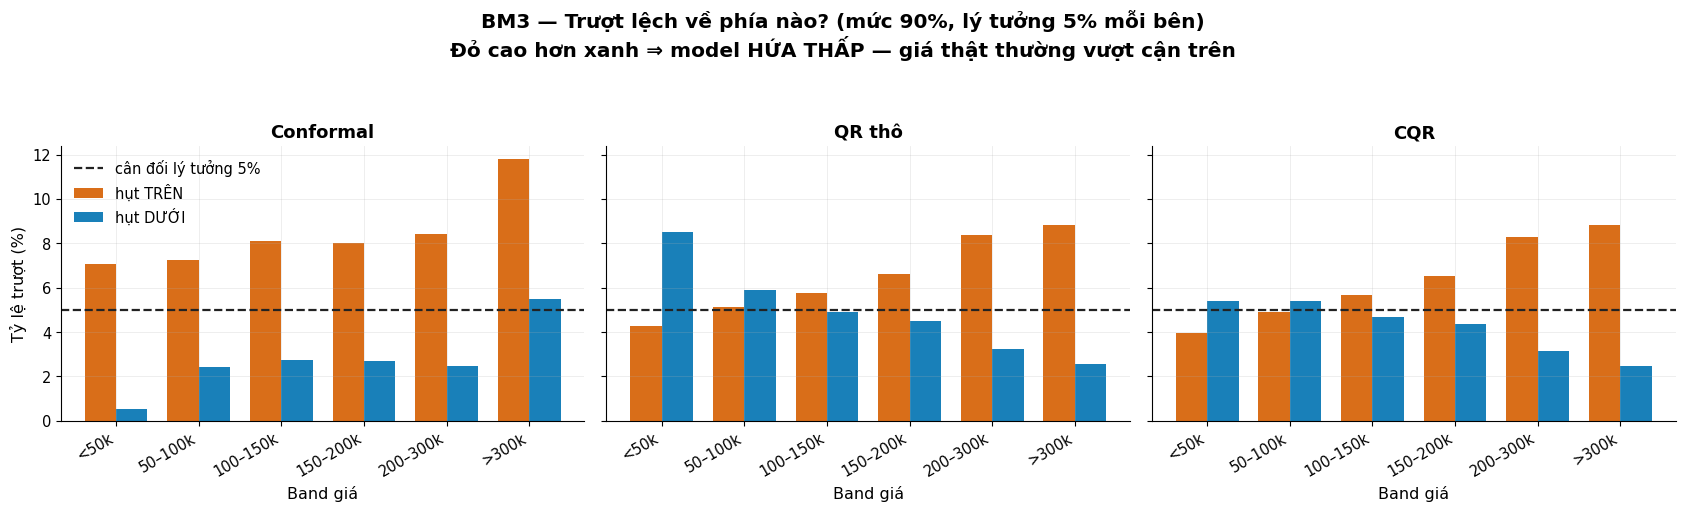

Conformal  : hut tren TB 8.44% · hut duoi TB 2.73% · ty le 3.1x
QR thô     : hut tren TB 6.50% · hut duoi TB 4.93% · ty le 1.3x
CQR        : hut tren TB 6.36% · hut duoi TB 4.24% · ty le 1.5x


In [23]:
# ═════════ HINH BM3 — bat doi xung: hut tren vs hut duoi ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for a, pp in zip(ax, PP):
    g = BANG[(pp, 0.90)]
    a.bar(x - .19, g.hut_tren*100, .38, color=RED, alpha=.9, label="hụt TRÊN")
    a.bar(x + .19, g.hut_duoi*100, .38, color=BLUE, alpha=.9, label="hụt DƯỚI")
    a.axhline(5, color=INK, lw=1.6, ls="--", label="cân đối lý tưởng 5%")
    a.set_xticks(x); a.set_xticklabels(TEN, rotation=30, ha="right")
    a.set_title(pp, fontweight="bold")
    a.set_xlabel("Band giá")
ax[0].set_ylabel("Tỷ lệ trượt (%)")
ax[0].legend(frameon=False)

fig.suptitle("BM3 — Trượt lệch về phía nào? (mức 90%, lý tưởng 5% mỗi bên)\n"
             "Đỏ cao hơn xanh ⇒ model HỨA THẤP — giá thật thường vượt cận trên",
             fontweight="bold", fontsize=14.5, y=1.06)
plt.tight_layout(); plt.savefig(HINH / "BM3_bat_doi_xung_3pp.png"); plt.show()

for pp in PP:
    g = BANG[(pp, 0.90)]
    print(f"{pp:11s}: hut tren TB {g.hut_tren.mean():.2%} · "
          f"hut duoi TB {g.hut_duoi.mean():.2%} · "
          f"ty le {g.hut_tren.mean()/max(g.hut_duoi.mean(),1e-9):.1f}x")

## 5. Kết luận

### Trả lời câu hỏi đặt ra ở đầu

Chạy cell dưới để lấy kết luận từ chính số vừa tính, không viết tay.

In [24]:
print("Band te nhat o tung to hop:")
for muc in MUCS:
    print(f"  {muc:.0%}: " + " · ".join(
        f"{pp} -> {BANG[(pp,muc)].cvg.idxmin()}" for pp in PP))

print()
print("Do DONG DEU giua cac band (lech toi da, diem) — cang nho cang tot:")
for pp in PP:
    v = [BANG[(pp, m)].lech.abs().max() for m in MUCS]
    print(f"  {pp:11s}: {' · '.join(f'{x:5.2f}' for x in v)}  -> TB {np.mean(v):.2f}")

print()
print("Nhung DONG DEU khong mien phi — do rong phai tra bao nhieu (muc 90%):")
for pp in PP:
    g = BANG[(pp, 0.90)]
    rong = (g.rong_tb * g.n).sum() / g.n.sum()
    print(f"  {pp:11s}: rong TB {rong:>8,.0f}d")

print()
print("=" * 70)
r_conf = (BANG[("Conformal", .90)].rong_tb * BANG[("Conformal", .90)].n).sum() / \
         BANG[("Conformal", .90)].n.sum()
r_cqr = (BANG[("CQR", .90)].rong_tb * BANG[("CQR", .90)].n).sum() / \
        BANG[("CQR", .90)].n.sum()
l_conf = np.mean([BANG[("Conformal", m)].lech.abs().max() for m in MUCS])
l_cqr = np.mean([BANG[("CQR", m)].lech.abs().max() for m in MUCS])
print("KET LUAN")
print("=" * 70)
print(f"  Conformal: dong deu {l_conf:.2f} diem · rong {r_conf:,.0f}d")
print(f"  CQR      : dong deu {l_cqr:.2f} diem · rong {r_cqr:,.0f}d")
print(f"  -> CQR deu hon {l_conf/l_cqr:.1f} lan, doi lay rong hon {r_cqr/r_conf-1:+.1%}")
print()
print("  Van de band gia KHONG phai tinh chat du lieu — QR va CQR gan nhu phang.")
print("  Nguyen nhan: Conformal chuan hoa ap MOT ty le q chung cho moi chuyen,")
print("  nen band gia cao (sai so tuong doi lon hon) bi cho khoang qua hep.")
print("  QR/CQR sinh phan vi RIENG cho tung chuyen nen tu thich ung.")

Band te nhat o tung to hop:
  70%: Conformal -> >300k · QR thô -> >300k · CQR -> >300k
  80%: Conformal -> >300k · QR thô -> >300k · CQR -> >300k
  90%: Conformal -> >300k · QR thô -> <50k · CQR -> 200–300k

Do DONG DEU giua cac band (lech toi da, diem) — cang nho cang tot:
  Conformal  : 10.05 ·  8.26 ·  7.28  -> TB 8.53
  QR thô     :  3.28 ·  3.73 ·  2.75  -> TB 3.25
  CQR        :  3.28 ·  3.57 ·  1.39  -> TB 2.75

Nhung DONG DEU khong mien phi — do rong phai tra bao nhieu (muc 90%):
  Conformal  : rong TB   72,630d
  QR thô     : rong TB   75,783d
  CQR        : rong TB   76,449d

KET LUAN
  Conformal: dong deu 8.53 diem · rong 72,630d
  CQR      : dong deu 2.75 diem · rong 76,449d
  -> CQR deu hon 3.1 lan, doi lay rong hon +5.3%

  Van de band gia KHONG phai tinh chat du lieu — QR va CQR gan nhu phang.
  Nguyen nhan: Conformal chuan hoa ap MOT ty le q chung cho moi chuyen,
  nen band gia cao (sai so tuong doi lon hon) bi cho khoang qua hep.
  QR/CQR sinh phan vi RIENG cho tung ch

---

# 4. Bản trình bày — chốt khuyến nghị

In [25]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
MUC = 0.90

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qc = pd.read_parquet(EVAL / "qr_pred_da_muc_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")
assert np.allclose(ut.gia_that.values, qt.gia_that.values), "khong khop hang!"

# ── A. Conformal chuan hoa ──
sai_cal = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
q_conf = np.quantile(sai_cal, MUC)
A_lo, A_hi = ut.hybrid_pred.values*(1-q_conf), ut.hybrid_pred.values*(1+q_conf)

# ── B. QR tho ──
B_lo, B_hi = qt.q05.values, qt.q95.values

# ── C. CQR ──
E = np.maximum(qc.q05.values - qc.gia_that.values, qc.gia_that.values - qc.q95.values)
k = min(int(np.ceil((len(qc)+1)*MUC)), len(qc))
q_cqr = np.sort(E)[k-1]
C_lo, C_hi = qt.q05.values - q_cqr, qt.q95.values + q_cqr

PP = {"A. Conformal chuẩn hoá": (A_lo, A_hi, BLUE),
      "B. QR thô":              (B_lo, B_hi, ORANGE),
      "C. CQR":                 (C_lo, C_hi, GREEN)}
ngan = ["Conformal", "QR thô", "CQR"]      # ten ngan de ve hinh
that = qt.gia_that.values

# ── Chon CHUYEN VI DU dung chung cho moi hinh ──
# Tieu chi: DIEN HINH tren CA HAI chieu — gia gan trung vi VA sai so gan trung vi.
# (khong chon chuyen sai it nhat de tranh cherry-pick)
_err = np.abs(that - ut.hybrid_pred.values) / ut.hybrid_pred.values
_gia_tv, _err_tv = np.median(ut.hybrid_pred.values), np.median(_err)
i_ref = int(np.argmin(np.abs(ut.hybrid_pred.values - _gia_tv)/_gia_tv
                      + 3*np.abs(_err - _err_tv)))
print(f"Chuyen vi du (dien hinh ca 2 chieu):")
print(f"   gia du doan {ut.hybrid_pred.values[i_ref]:,.0f}d  "
      f"(trung vi {_gia_tv:,.0f}d)")
print(f"   gia that    {that[i_ref]:,.0f}d  ->  sai {_err[i_ref]:.2%}  "
      f"(sai so trung vi {_err_tv:.2%})")

KQ = {}
for ten, (lo, hi, _) in PP.items():
    trong = (that >= lo) & (that <= hi)
    KQ[ten] = dict(cov=trong.mean(), rong=float(np.mean(hi-lo)), trong=trong)

print(f"Calibration {len(uc):,}  |  Test {len(ut):,}")
print(f"Muc tin cay: {MUC:.0%}\n")
print(f"  A. Conformal : q = ±{q_conf:.2%}")
print(f"  B. QR tho    : q05 – q95 (train thang)")
print(f"  C. CQR       : q05 – q95, noi them {q_cqr:+,.0f}d moi ben")

Chuyen vi du (dien hinh ca 2 chieu):
   gia du doan 115,058d  (trung vi 115,335d)
   gia that    101,000d  ->  sai 12.22%  (sai so trung vi 12.21%)
Calibration 615,908  |  Test 864,360
Muc tin cay: 90%

  A. Conformal : q = ±30.09%
  B. QR tho    : q05 – q95 (train thang)
  C. CQR       : q05 – q95, noi them +333d moi ben


## 1. Ba phương pháp dựng khoảng khác nhau thế nào

Cùng **một chuyến**, ba cách làm khác hẳn nhau.

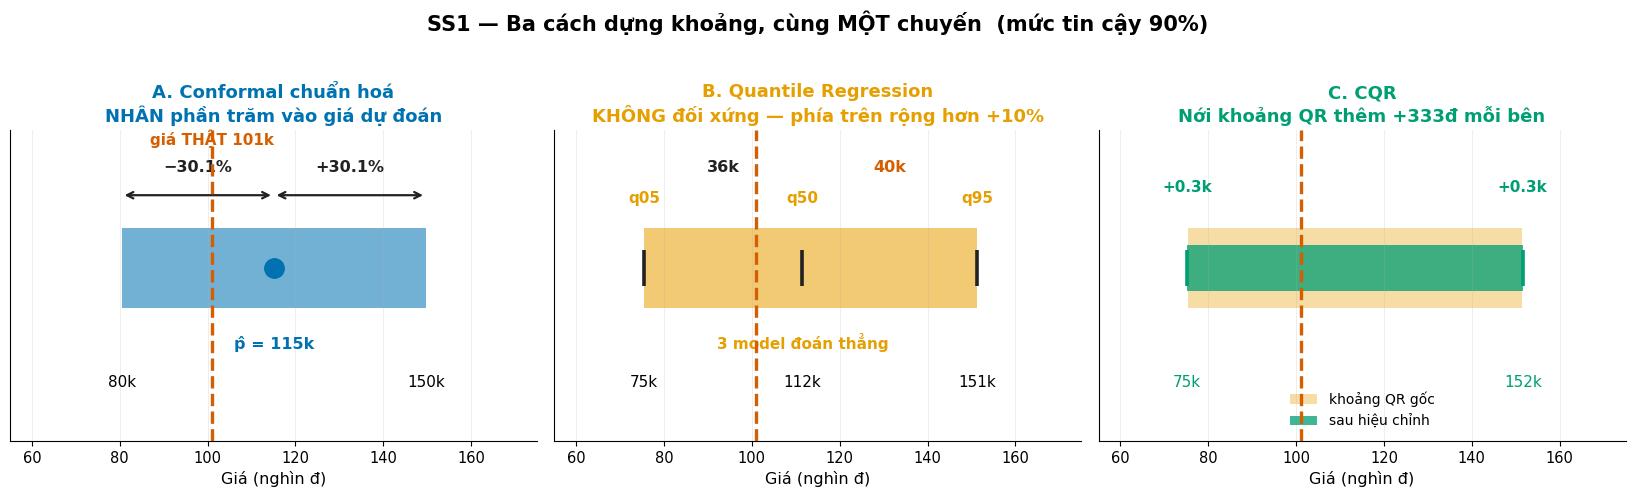

In [26]:
# ═════════ HINH SS1 — co che 3 phuong phap ═════════
i = i_ref                      # dung chung chuyen vi du voi cac hinh khac
p_hat, t_that = ut.hybrid_pred.values[i], that[i]

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))

# --- A ---
a = ax[0]
a.barh(0, (A_hi[i]-A_lo[i])/1000, left=A_lo[i]/1000, height=.42, color=BLUE, alpha=.55)
a.plot(p_hat/1000, 0, "o", color=BLUE, ms=14, zorder=5)
a.annotate("", xy=(A_lo[i]/1000, .38), xytext=(p_hat/1000, .38),
           arrowprops=dict(arrowstyle="<->", color=INK, lw=1.6))
a.annotate("", xy=(A_hi[i]/1000, .38), xytext=(p_hat/1000, .38),
           arrowprops=dict(arrowstyle="<->", color=INK, lw=1.6))
a.text((A_lo[i]+p_hat)/2000, .50, f"−{q_conf:.1%}", ha="center", fontsize=11.5,
       fontweight="bold", color=INK)
a.text((A_hi[i]+p_hat)/2000, .50, f"+{q_conf:.1%}", ha="center", fontsize=11.5,
       fontweight="bold", color=INK)
a.text(p_hat/1000, -.42, f"p̂ = {p_hat/1000:.0f}k", ha="center", fontsize=11.5,
       fontweight="bold", color=BLUE)
a.text(A_lo[i]/1000, -.62, f"{A_lo[i]/1000:.0f}k", ha="center", fontsize=11)
a.text(A_hi[i]/1000, -.62, f"{A_hi[i]/1000:.0f}k", ha="center", fontsize=11)
a.set_title("A. Conformal chuẩn hoá\nNHÂN phần trăm vào giá dự đoán",
            fontweight="bold", color=BLUE)

# --- B ---
b = ax[1]
b.barh(0, (B_hi[i]-B_lo[i])/1000, left=B_lo[i]/1000, height=.42, color=ORANGE, alpha=.55)
for v, ten, dy in [(qt.q05.values[i], "q05", 0), (qt.q50.values[i], "q50", 0),
                   (qt.q95.values[i], "q95", 0)]:
    b.plot(v/1000, 0, "|", color=INK, ms=26, mew=2.6, zorder=5)
    b.text(v/1000, .34, ten, ha="center", fontsize=11, fontweight="bold", color=ORANGE)
    b.text(v/1000, -.62, f"{v/1000:.0f}k", ha="center", fontsize=11)
d1 = (qt.q50.values[i]-B_lo[i])/1000
d2 = (B_hi[i]-qt.q50.values[i])/1000
b.text((B_lo[i]+qt.q50.values[i])/2000, .50, f"{d1:.0f}k", ha="center",
       fontsize=11.5, fontweight="bold", color=INK)
b.text((B_hi[i]+qt.q50.values[i])/2000, .50, f"{d2:.0f}k", ha="center",
       fontsize=11.5, fontweight="bold", color=RED)
b.text(qt.q50.values[i]/1000, -.42, "3 model đoán thẳng", ha="center",
       fontsize=11, fontweight="bold", color=ORANGE)
b.set_title(f"B. Quantile Regression\nKHÔNG đối xứng — phía trên rộng hơn {d2/d1-1:+.0%}",
            fontweight="bold", color=ORANGE)

# --- C ---
c = ax[2]
c.barh(0, (B_hi[i]-B_lo[i])/1000, left=B_lo[i]/1000, height=.42, color=ORANGE,
       alpha=.35, label="khoảng QR gốc")
c.barh(0, (C_hi[i]-C_lo[i])/1000, left=C_lo[i]/1000, height=.24, color=GREEN,
       alpha=.75, label="sau hiệu chỉnh")
for v in (C_lo[i], C_hi[i]):
    c.plot(v/1000, 0, "|", color=GREEN, ms=26, mew=2.6, zorder=5)
    c.text(v/1000, -.62, f"{v/1000:.0f}k", ha="center", fontsize=11, color=GREEN)
c.text((B_lo[i]+C_lo[i])/2000, .40, f"{q_cqr/1000:+.1f}k", ha="center",
       fontsize=11, fontweight="bold", color=GREEN)
c.text((B_hi[i]+C_hi[i])/2000, .40, f"{q_cqr/1000:+.1f}k", ha="center",
       fontsize=11, fontweight="bold", color=GREEN)
c.legend(frameon=False, loc="lower center", fontsize=10)
c.set_title(f"C. CQR\nNới khoảng QR thêm {q_cqr:+,.0f}đ mỗi bên",
            fontweight="bold", color=GREEN)

for a_ in ax:
    a_.axvline(t_that/1000, color=RED, lw=2.4, ls="--", zorder=6)
    a_.set_ylim(-.9, .72); a_.set_yticks([])
    a_.set_xlim(55, 175); a_.set_xlabel("Giá (nghìn đ)")
    a_.grid(axis="y", alpha=0)
ax[0].text(t_that/1000, .64, f"giá THẬT {t_that/1000:.0f}k", ha="center",
           fontsize=11, fontweight="bold", color=RED)

fig.suptitle(f"SS1 — Ba cách dựng khoảng, cùng MỘT chuyến  (mức tin cậy {MUC:.0%})",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "SS1_co_che_3_pp.png"); plt.show()

## 2. Kết quả — 3 phương pháp × 3 mức tin cậy

⚠️ **Độ rộng dưới đây là TRUNG BÌNH** trên 864.360 chuyến. Mỗi chuyến có khoảng riêng — chuyến rẻ
khoảng hẹp, chuyến đắt khoảng rộng.

In [27]:
MUCS = [0.70, 0.80, 0.90]
PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
TEN3 = ["Conformal chuẩn hoá", "QR thô", "CQR"]
MAU3 = [BLUE, ORANGE, GREEN]
O = {}      # (phuong phap, muc) -> dict

for m in MUCS:
    lo_c, hi_c = PV[m]

    # A. Conformal chuan hoa
    q = np.quantile(sai_cal, m)
    O[("Conformal chuẩn hoá", m)] = dict(
        lo=ut.hybrid_pred.values*(1-q), hi=ut.hybrid_pred.values*(1+q),
        tham_so=f"±{q:.2%}", q=q)

    # B. QR tho
    O[("QR thô", m)] = dict(lo=qt[lo_c].values, hi=qt[hi_c].values,
                            tham_so=f"{lo_c}–{hi_c}")

    # C. CQR
    E_ = np.maximum(qc[lo_c].values - qc.gia_that.values,
                    qc.gia_that.values - qc[hi_c].values)
    k_ = min(int(np.ceil((len(qc)+1)*m)), len(qc))
    qcq = np.sort(E_)[k_-1]
    O[("CQR", m)] = dict(lo=qt[lo_c].values - qcq, hi=qt[hi_c].values + qcq,
                         tham_so=f"{lo_c}–{hi_c} {qcq:+,.0f}đ", q_cqr=qcq)

for kk, v in O.items():
    trong = (that >= v["lo"]) & (that <= v["hi"])
    v["cov"] = trong.mean()
    v["rong"] = float(np.mean(v["hi"] - v["lo"]))
    v["trong"] = trong

# Cong bang giua nhom o muc 90% — dung cho Phan 4 va ket luan
_t = pd.DataFrame({"gio": qt.gio_vn.values, "km": qt.quang_duong.values})
_t["nhom_km"] = pd.qcut(_t.km, 8, labels=False, duplicates="drop")
_t["mua"] = qt.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values
for ten in PP:
    _t["tr"] = KQ[ten]["trong"]
    KQ[ten]["lech_dk"] = max(
        abs(_t.groupby("gio").tr.mean()*100 - MUC*100).max(),
        abs(_t.groupby("nhom_km").tr.mean()*100 - MUC*100).max(),
        abs(_t.groupby("mua").tr.mean()*100 - MUC*100).max())

# ═══ BANG A — do rong TRUNG BINH ═══
BA = pd.DataFrame(
    [[f"{O[(pp, m)]['rong']:,.0f}đ" for pp in TEN3] for m in MUCS],
    index=[f"{m:.0%}" for m in MUCS], columns=TEN3)
BA.index.name = "Độ tin cậy"
print("BANG A — KHOANG GIA TRUNG BINH (rong bao nhieu dong)")
display(BA)

# ═══ BANG B — coverage dat duoc ═══
BB = pd.DataFrame(
    [[f"{O[(pp, m)]['cov']:.2%}" for pp in TEN3] for m in MUCS],
    index=[f"{m:.0%}" for m in MUCS], columns=TEN3)
BB.index.name = "Độ tin cậy"
print("BANG B — COVERAGE DAT DUOC (so voi danh muc)")
display(BB)

BANG A — KHOANG GIA TRUNG BINH (rong bao nhieu dong)


,Conformal chuẩn hoá,QR thô,CQR
Độ tin cậy,,,
70%,"45,320đ","47,406đ","47,684đ"
80%,"56,118đ","58,772đ","59,284đ"
90%,"72,630đ","75,783đ","76,449đ"


BANG B — COVERAGE DAT DUOC (so voi danh muc)


,Conformal chuẩn hoá,QR thô,CQR
Độ tin cậy,,,
70%,69.73%,68.88%,69.26%
80%,79.60%,78.89%,79.44%
90%,89.55%,89.09%,89.54%


### Khoảng giá cụ thể — để nói cho dễ hình dung

Bảng trên là độ rộng trung bình. Bảng dưới là **khoảng thật của một chuyến cụ thể** — dạng này dễ
nói khi trình bày.

In [28]:
p_ref, t_ref = ut.hybrid_pred.values[i_ref], that[i_ref]

rows = []
for m in MUCS:
    for pp in TEN3:
        v = O[(pp, m)]
        rows.append({"Độ tin cậy": f"{m:.0%}", "Phương pháp": pp,
                     "Khoảng giá": f"{v['lo'][i_ref]:,.0f} – {v['hi'][i_ref]:,.0f}đ",
                     "Rộng": f"{v['hi'][i_ref]-v['lo'][i_ref]:,.0f}đ",
                     "Trúng?": "trúng" if v["lo"][i_ref] <= t_ref <= v["hi"][i_ref]
                               else "TRƯỢT"})
BC = pd.DataFrame(rows)
print(f"BANG C — CHUYEN VI DU: gia du doan {p_ref:,.0f}d  |  gia THAT {t_ref:,.0f}d")
display(BC.pivot(index="Độ tin cậy", columns="Phương pháp",
                 values="Khoảng giá").reindex([f"{m:.0%}" for m in MUCS])[TEN3])
display(BC)

BANG C — CHUYEN VI DU: gia du doan 115,058d  |  gia THAT 101,000d


Phương pháp,Conformal chuẩn hoá,QR thô,CQR
Độ tin cậy,,,
70%,"93,455 – 136,662đ","85,812 – 132,083đ","85,673 – 132,222đ"
80%,"88,308 – 141,809đ","82,039 – 137,470đ","81,783 – 137,726đ"
90%,"80,437 – 149,680đ","75,414 – 151,355đ","75,081 – 151,688đ"


,Độ tin cậy,Phương pháp,Khoảng giá,Rộng,Trúng?
0,70%,Conformal chuẩn hoá,"93,455 – 136,662đ","43,207đ",trúng
1,70%,QR thô,"85,812 – 132,083đ","46,271đ",trúng
2,70%,CQR,"85,673 – 132,222đ","46,549đ",trúng
3,80%,Conformal chuẩn hoá,"88,308 – 141,809đ","53,500đ",trúng
4,80%,QR thô,"82,039 – 137,470đ","55,432đ",trúng
5,80%,CQR,"81,783 – 137,726đ","55,944đ",trúng
6,90%,Conformal chuẩn hoá,"80,437 – 149,680đ","69,242đ",trúng
7,90%,QR thô,"75,414 – 151,355đ","75,940đ",trúng
8,90%,CQR,"75,081 – 151,688đ","76,606đ",trúng


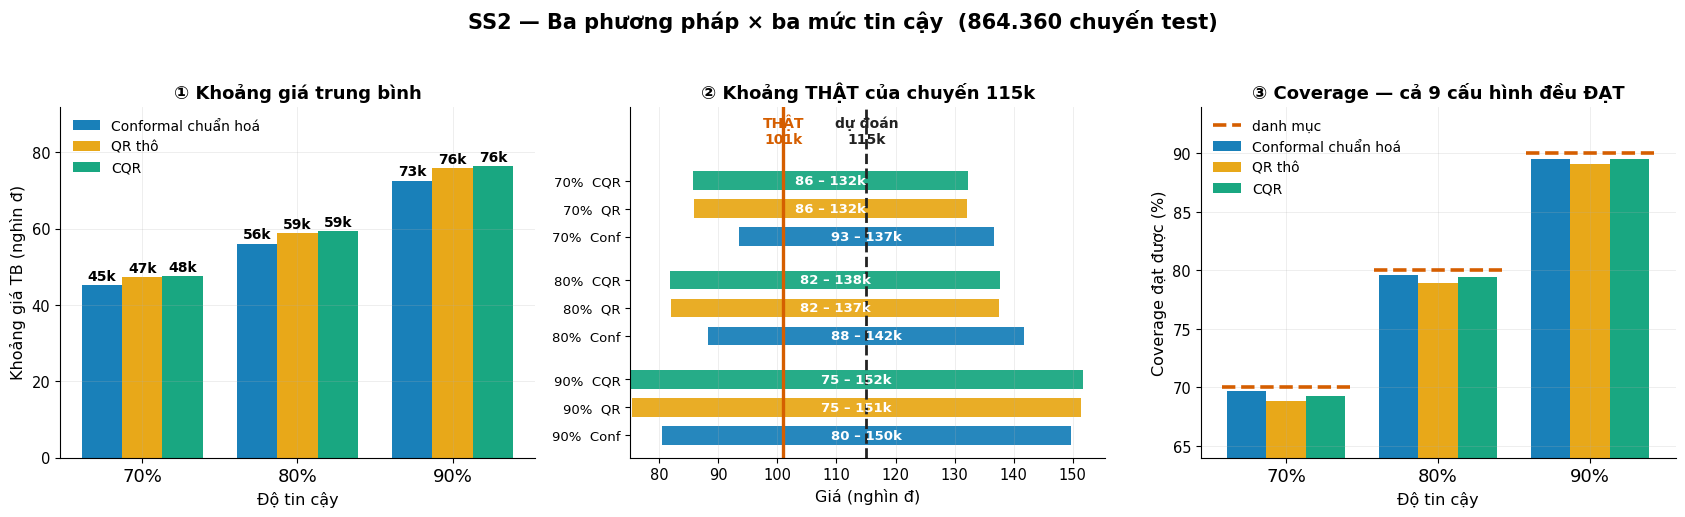

NHAN XET:
  Doi MUC 90%->70% : khoang hep 38%
  Doi PHUONG PHAP  : chenh chi 5.3%
  => Chon MUC anh huong lon hon nhieu so voi chon PHUONG PHAP.


In [29]:
# ═════════ HINH SS2 — 3 phuong phap x 3 muc ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5.0))
x = np.arange(3); w = .26

# ① Do rong TB
for j, pp in enumerate(TEN3):
    v = [O[(pp, m)]["rong"]/1000 for m in MUCS]
    b = ax[0].bar(x + (j-1)*w, v, w, color=MAU3[j], alpha=.9, label=pp)
    for bb, val in zip(b, v):
        ax[0].text(bb.get_x()+bb.get_width()/2, val+1.3, f"{val:.0f}k",
                   ha="center", fontsize=10, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=13)
ax[0].set_xlabel("Độ tin cậy"); ax[0].set_ylabel("Khoảng giá TB (nghìn đ)")
ax[0].set_ylim(0, 92); ax[0].legend(frameon=False, fontsize=10)
ax[0].set_title("① Khoảng giá trung bình", fontweight="bold")

# ② Khoang that cua chuyen vi du
y = 0
nhan_y, nhan_t = [], []
for m in sorted(MUCS, reverse=True):
    for j, pp in enumerate(TEN3):
        v = O[(pp, m)]
        lo_, hi_ = v["lo"][i_ref]/1000, v["hi"][i_ref]/1000
        ax[1].barh(y, hi_-lo_, left=lo_, height=.66, color=MAU3[j], alpha=.85)
        ax[1].text((lo_+hi_)/2, y, f"{lo_:.0f} – {hi_:.0f}k", ha="center",
                   va="center", fontsize=9.5, fontweight="bold", color="white")
        nhan_y.append(y); nhan_t.append(f"{m:.0%}  {['Conf','QR','CQR'][j]}")
        y += 1
    y += .55
ax[1].axvline(p_ref/1000, color=INK, lw=2, ls="--")
ax[1].axvline(t_ref/1000, color=RED, lw=2.4)
ax[1].text(p_ref/1000, y-.2, f"dự đoán\n{p_ref/1000:.0f}k", ha="center",
           fontsize=10, fontweight="bold", color=INK)
ax[1].text(t_ref/1000, y-.2, f"THẬT\n{t_ref/1000:.0f}k", ha="center",
           fontsize=10, fontweight="bold", color=RED)
ax[1].set_yticks(nhan_y); ax[1].set_yticklabels(nhan_t, fontsize=9.5)
ax[1].set_xlabel("Giá (nghìn đ)"); ax[1].set_ylim(-.8, y+1.1)
ax[1].grid(axis="y", alpha=0)
ax[1].set_title(f"② Khoảng THẬT của chuyến {p_ref/1000:.0f}k", fontweight="bold")

# ③ Coverage
for j, pp in enumerate(TEN3):
    v = [O[(pp, m)]["cov"]*100 for m in MUCS]
    ax[2].bar(x + (j-1)*w, v, w, color=MAU3[j], alpha=.9, label=pp)
for j_, m in enumerate(MUCS):
    ax[2].plot([j_-.42, j_+.42], [m*100, m*100], color=RED, lw=2.6, ls="--", zorder=5)
ax[2].plot([], [], color=RED, lw=2.6, ls="--", label="danh mục")
ax[2].set_xticks(x); ax[2].set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=13)
ax[2].set_xlabel("Độ tin cậy"); ax[2].set_ylabel("Coverage đạt được (%)")
ax[2].set_ylim(64, 94); ax[2].legend(frameon=False, fontsize=10)
ax[2].set_title("③ Coverage — cả 9 cấu hình đều ĐẠT", fontweight="bold")

fig.suptitle("SS2 — Ba phương pháp × ba mức tin cậy  (864.360 chuyến test)",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "SS2_ket_qua.png"); plt.show()

print("NHAN XET:")
r90 = [O[(pp, 0.90)]["rong"] for pp in TEN3]
r70 = [O[(pp, 0.70)]["rong"] for pp in TEN3]
print(f"  Doi MUC 90%->70% : khoang hep {(1-np.mean(r70)/np.mean(r90))*100:.0f}%")
print(f"  Doi PHUONG PHAP  : chenh chi {(max(r90)/min(r90)-1)*100:.1f}%")
print("  => Chon MUC anh huong lon hon nhieu so voi chon PHUONG PHAP.")

### Đọc bảng

| Độ tin cậy | Khoảng giá trung bình |
|---|---|
| **90%** | ~72.700 – 76.400đ tuỳ phương pháp |
| **80%** | ~56.100 – 59.300đ |
| **70%** | ~45.300 – 47.700đ |

**Hai điều rút ra:**

1. **Chọn mức tin cậy quan trọng hơn chọn phương pháp.** Hạ từ 90% xuống 70% làm khoảng hẹp
   **~38%**. Còn đổi phương pháp trong cùng một mức chỉ chênh **~5%**.
2. **Cả 9 cấu hình đều đạt coverage danh mục** — nên tiêu chí này không phân biệt được. Thứ phân
   biệt nằm ở Phần 4.

### Hạ mức tin cậy thì **trượt** bao nhiêu?

"Trượt" = giá thật **nằm ngoài** khoảng. Đây là **cái giá** phải trả khi muốn khoảng hẹp hơn.

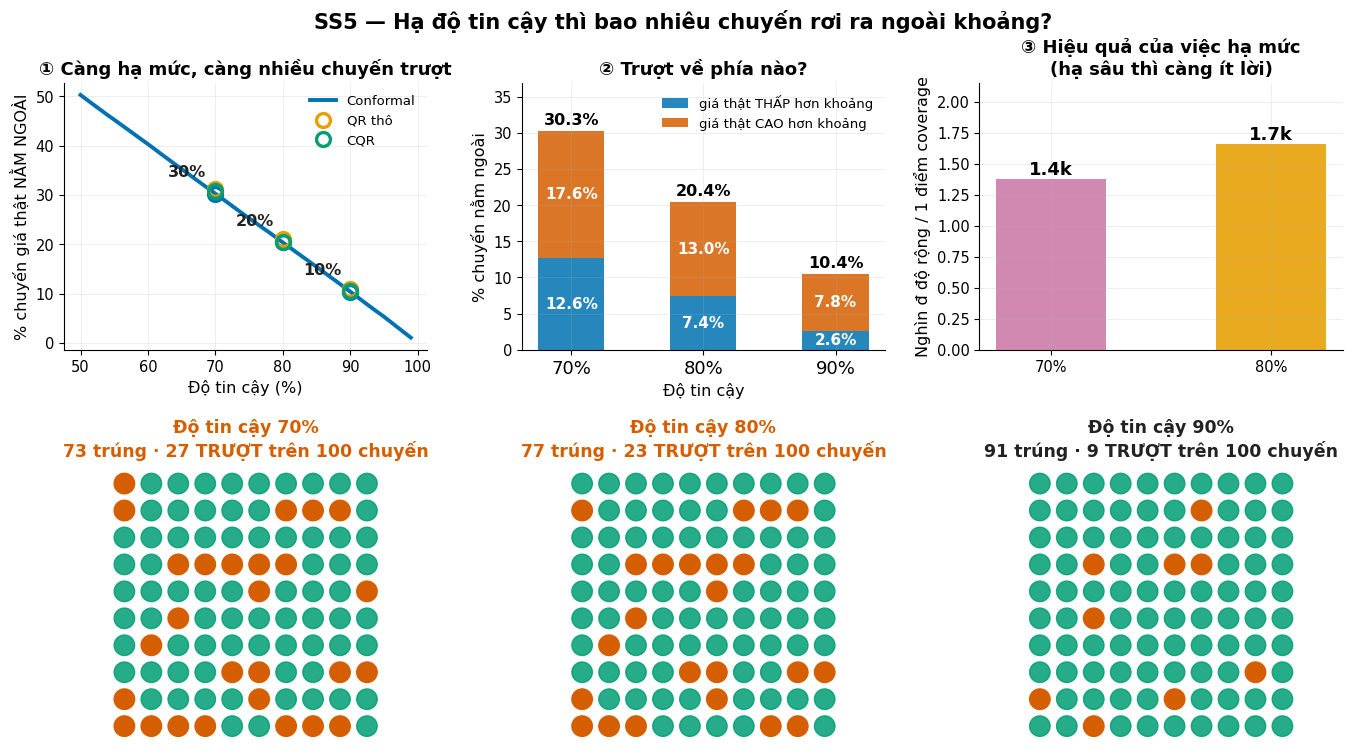

   Muc    Do rong TB   % nam ngoai   Truot/1.000     duoi     tren
--------------------------------------------------------------------
  70%       45,320d         30.3%           303    12.6%    17.6%
  80%       56,118d         20.4%           204     7.4%    13.0%
  90%       72,630d         10.4%           104     2.6%     7.8%

=> Truot LEN nhieu hon truot XUONG 2.0 lan.
   Ly do: gia co duoi lech PHAI — surge chi nhan LEN chu khong nhan xuong.
   Khoang cua Conformal doi xung nen khong bat duoc do lech nay.


In [30]:
# ═════════ HINH SS5 — ha muc thi truot bao nhieu ═════════
from matplotlib.gridspec import GridSpec

MUC_QUET = np.linspace(.50, .99, 50)
p_hat_all = ut.hybrid_pred.values

# Quet lien tuc cho Conformal + 3 diem cho ca 3 phuong phap
ngoai_cf = []
for m in MUC_QUET:
    q = np.quantile(sai_cal, m)
    ngoai_cf.append(1 - ((that >= p_hat_all*(1-q)) & (that <= p_hat_all*(1+q))).mean())
ngoai_cf = np.array(ngoai_cf)

fig = plt.figure(figsize=(16.5, 8.6))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1, 1.05], hspace=.42, wspace=.26)

# ── ① Duong cong % nam ngoai ──
a = fig.add_subplot(gs[0, 0])
a.plot(MUC_QUET*100, ngoai_cf*100, lw=2.8, color=BLUE, label="Conformal")
for j, pp in enumerate(TEN3):
    v = [(1-O[(pp, m)]["cov"])*100 for m in MUCS]
    a.plot([m*100 for m in MUCS], v, "o", ms=10, mfc="none", mew=2.4,
           color=MAU3[j], label=pp if j else None)
for m in MUCS:
    v = (1-O[("Conformal chuẩn hoá", m)]["cov"])*100
    a.annotate(f"{v:.0f}%", xy=(m*100, v), xytext=(m*100-7, v+3.4),
               fontsize=11.5, fontweight="bold", color=INK)
a.set_xlabel("Độ tin cậy (%)"); a.set_ylabel("% chuyến giá thật NẰM NGOÀI")
a.set_title("① Càng hạ mức, càng nhiều chuyến trượt", fontweight="bold")
a.legend(frameon=False, fontsize=9.5)

# ── ② Truot LEN hay truot XUONG ──
b = fig.add_subplot(gs[0, 1])
duoi, tren = [], []
for m in MUCS:
    v = O[("Conformal chuẩn hoá", m)]
    duoi.append((that < v["lo"]).mean()*100)
    tren.append((that > v["hi"]).mean()*100)
x = np.arange(3)
b.bar(x, duoi, .5, color=BLUE, alpha=.85, label="giá thật THẤP hơn khoảng")
b.bar(x, tren, .5, bottom=duoi, color=RED, alpha=.85, label="giá thật CAO hơn khoảng")
for j in range(3):
    b.text(j, duoi[j]/2, f"{duoi[j]:.1f}%", ha="center", va="center",
           fontsize=11, fontweight="bold", color="white")
    b.text(j, duoi[j]+tren[j]/2, f"{tren[j]:.1f}%", ha="center", va="center",
           fontsize=11, fontweight="bold", color="white")
    b.text(j, duoi[j]+tren[j]+.9, f"{duoi[j]+tren[j]:.1f}%", ha="center",
           fontsize=11.5, fontweight="bold")
b.set_xticks(x); b.set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=13)
b.set_xlabel("Độ tin cậy"); b.set_ylabel("% chuyến nằm ngoài")
b.set_ylim(0, max(np.array(duoi)+np.array(tren))*1.22)
b.legend(frameon=False, fontsize=9.5, loc="upper right")
b.set_title("② Trượt về phía nào?", fontweight="bold")

# ── ③ Doi 1 diem coverage lay duoc bao nhieu do rong ──
c = fig.add_subplot(gs[0, 2])
rg = [O[("Conformal chuẩn hoá", m)]["rong"] for m in MUCS]
doi = [(rg[2]-rg[j])/1000 / ((O[("Conformal chuẩn hoá", 0.90)]["cov"]
                              - O[("Conformal chuẩn hoá", MUCS[j])]["cov"])*100)
       for j in range(2)]
bb = c.bar([f"{m:.0%}" for m in MUCS[:2]], doi, .5, color=[PURPLE, ORANGE], alpha=.88)
for r_, v in zip(bb, doi):
    c.text(r_.get_x()+r_.get_width()/2, v+.04, f"{v:.1f}k", ha="center",
           fontsize=13, fontweight="bold")
c.set_ylabel("Nghìn đ độ rộng / 1 điểm coverage")
c.set_ylim(0, max(doi)*1.3)
c.set_title("③ Hiệu quả của việc hạ mức\n(hạ sâu thì càng ít lời)", fontweight="bold")

# ── ④⑤⑥ Luoi 100 chuyen ──
rng100 = np.random.default_rng(2024)
mau_100 = rng100.choice(len(that), 100, replace=False)
for j, m in enumerate(MUCS):
    a_ = fig.add_subplot(gs[1, j])
    v = O[("Conformal chuẩn hoá", m)]
    tr = v["trong"][mau_100]
    n_ngoai = int((~tr).sum())
    for k_ in range(100):
        r_, c_ = divmod(k_, 10)
        a_.add_patch(plt.Circle((c_, 9-r_), .38,
                                color=GREEN if tr[k_] else RED,
                                alpha=.85 if tr[k_] else 1.0))
    a_.set_xlim(-.7, 9.7); a_.set_ylim(-.7, 9.7); a_.set_aspect("equal")
    a_.set_xticks([]); a_.set_yticks([]); a_.grid(alpha=0)
    for sp in a_.spines.values():
        sp.set_visible(False)
    a_.set_title(f"Độ tin cậy {m:.0%}\n{100-n_ngoai} trúng · "
                 f"{n_ngoai} TRƯỢT trên 100 chuyến",
                 fontweight="bold", fontsize=12.5,
                 color=INK if m == .90 else RED)

fig.suptitle("SS5 — Hạ độ tin cậy thì bao nhiêu chuyến rơi ra ngoài khoảng?",
             fontweight="bold", fontsize=15, y=.965)
plt.savefig(HINH / "SS5_truot_theo_muc.png", bbox_inches="tight"); plt.show()

print(f"{'Muc':>6s} {'Do rong TB':>13s} {'% nam ngoai':>13s} {'Truot/1.000':>13s} "
      f"{'duoi':>8s} {'tren':>8s}")
print("-" * 68)
for j, m in enumerate(MUCS):
    v = O[("Conformal chuẩn hoá", m)]
    print(f"{m:>5.0%} {v['rong']:>12,.0f}d {(1-v['cov'])*100:>12.1f}% "
          f"{(1-v['cov'])*1000:>13.0f} {duoi[j]:>7.1f}% {tren[j]:>7.1f}%")
print()
print(f"=> Truot LEN nhieu hon truot XUONG "
      f"{np.mean(np.array(tren)/np.array(duoi)):.1f} lan.")
print("   Ly do: gia co duoi lech PHAI — surge chi nhan LEN chu khong nhan xuong.")
print("   Khoang cua Conformal doi xung nen khong bat duoc do lech nay.")

## 3. Quy về **tỷ lệ** — nhìn rõ khác biệt giữa 3 phương pháp

Vẽ bằng đồng thì mỗi chuyến một thang giá, khó so. Chia mọi thứ cho **giá dự đoán `p̂`** thì tất cả
về cùng một thang: **1,0 = đúng bằng giá dự đoán**.

| Đọc thế nào | |
|---|---|
| `1,0` | Giá thật đúng bằng dự đoán |
| `0,8` | Giá thật thấp hơn dự đoán 20% |
| `1,3` | Giá thật cao hơn dự đoán 30% |

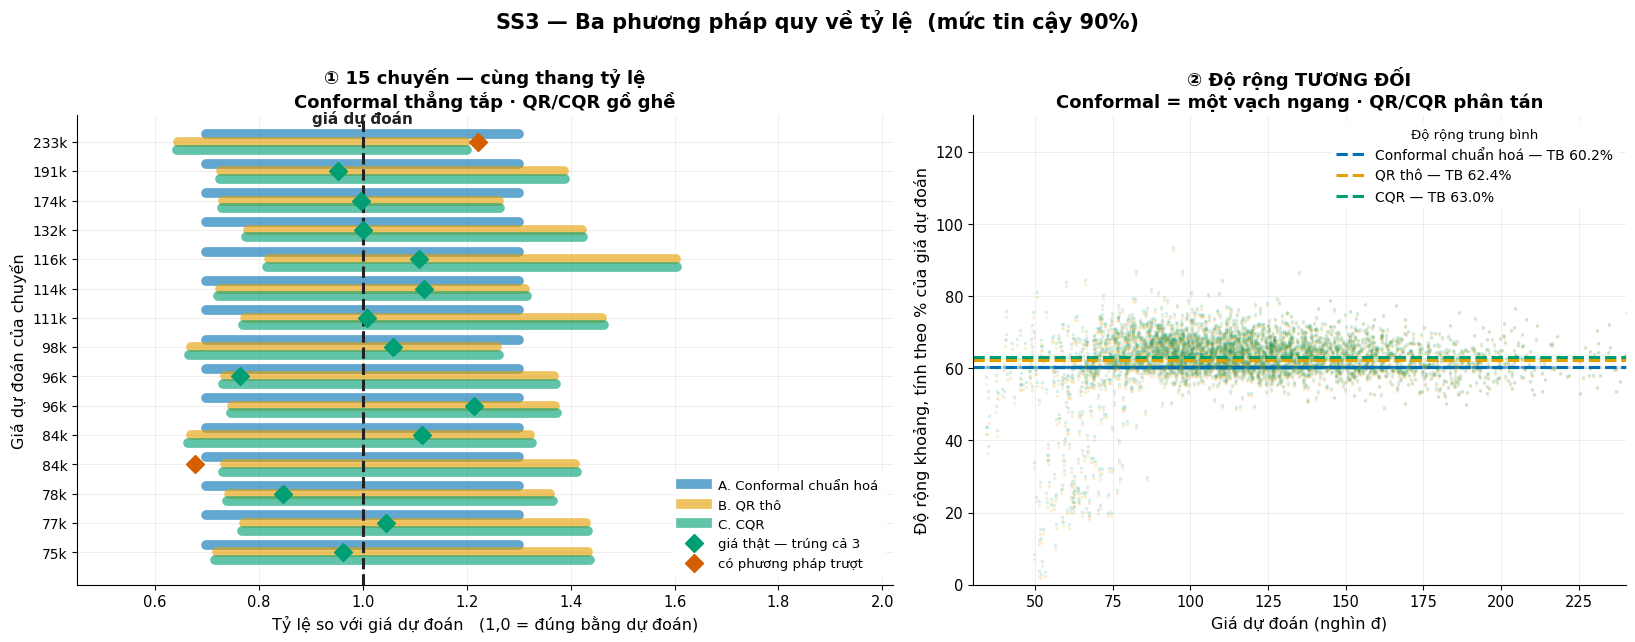

DO RONG TUONG DOI (% cua gia du doan):
                                 TB      std      min      max
--------------------------------------------------------------
  A. Conformal chuẩn hoá      60.2%     0.0%    60.2%    60.2%
  B. QR thô                   62.4%     7.9%    -1.3%   145.7%
  C. CQR                      63.0%     7.8%    -0.0%   147.4%

=> Conformal: std = 0 — MOI chuyen deu dung mot ty le.
   QR/CQR   : std > 0 — ty le THAY DOI theo do kho tung chuyen.


In [31]:
# ═════════ HINH SS3 — quy ve ty le ═════════
rng = np.random.default_rng(3)
n = 15
idx = rng.choice(len(qt), n, replace=False)
idx = idx[np.argsort(ut.hybrid_pred.values[idx])]
ph = ut.hybrid_pred.values

fig, ax = plt.subplots(1, 2, figsize=(16.5, 6.4),
                       gridspec_kw={"width_ratios": [1.25, 1]})

# ── ① 15 chuyen, quy ve ty le ──
off = {0: .26, 1: 0.0, 2: -.26}
for j, pp in enumerate(PP):
    lo, hi, col = PP[pp]
    for r, i_ in enumerate(idx):
        ax[0].plot([lo[i_]/ph[i_], hi[i_]/ph[i_]], [r+off[j]]*2, lw=7,
                   color=col, alpha=.62, solid_capstyle="round")
for r, i_ in enumerate(idx):
    trung = all(PP[k][0][i_] <= that[i_] <= PP[k][1][i_] for k in PP)
    ax[0].plot(that[i_]/ph[i_], r, "D", ms=9, zorder=6,
               color=GREEN if trung else RED)
ax[0].axvline(1.0, color=INK, lw=2.2, ls="--", zorder=4)
ax[0].text(1.0, n-.35, "giá dự đoán", ha="center", fontsize=11,
           fontweight="bold", color=INK)
for j, pp in enumerate(PP):
    ax[0].plot([], [], lw=7, color=PP[pp][2], alpha=.62, label=pp)
ax[0].plot([], [], "D", color=GREEN, ms=9, label="giá thật — trúng cả 3")
ax[0].plot([], [], "D", color=RED, ms=9, label="có phương pháp trượt")
ax[0].set_yticks(range(n))
ax[0].set_yticklabels([f"{ph[i]/1000:.0f}k" for i in idx], fontsize=10)
ax[0].set_ylabel("Giá dự đoán của chuyến")
ax[0].set_xlabel("Tỷ lệ so với giá dự đoán   (1,0 = đúng bằng dự đoán)")
ax[0].set_xlim(.45, 2.02); ax[0].set_ylim(-1.1, n-.1)
ax[0].legend(frameon=True, framealpha=.95, edgecolor="none", fontsize=9.5,
             loc="lower right", borderpad=.6)
ax[0].set_title("① 15 chuyến — cùng thang tỷ lệ\n"
                "Conformal thẳng tắp · QR/CQR gồ ghề",
                fontweight="bold", fontsize=13)

# ── ② Do rong TUONG DOI theo gia du doan ──
mau_v = rng.choice(len(qt), 4000, replace=False)
for j, pp in enumerate(PP):
    lo, hi, col = PP[pp]
    ax[1].scatter(ph[mau_v]/1000, (hi[mau_v]-lo[mau_v])/ph[mau_v]*100,
                  s=6, alpha=.16, color=col, lw=0)
for j, pp in enumerate(PP):
    lo, hi, col = PP[pp]
    tb = np.mean((hi-lo)/ph)*100
    ax[1].axhline(tb, color=col, lw=2.2, ls="--",
                  label=f"{pp.split('. ')[1]} — TB {tb:.1f}%")
ax[1].legend(frameon=True, framealpha=.95, edgecolor="none",
             fontsize=10, loc="upper right", title="Độ rộng trung bình",
             title_fontsize=9.5)
ax[1].set_xlim(30, 240); ax[1].set_ylim(0, 130)
ax[1].set_xlabel("Giá dự đoán (nghìn đ)")
ax[1].set_ylabel("Độ rộng khoảng, tính theo % của giá dự đoán")
ax[1].set_title("② Độ rộng TƯƠNG ĐỐI\n"
                "Conformal = một vạch ngang · QR/CQR phân tán",
                fontweight="bold", fontsize=13)

fig.suptitle(f"SS3 — Ba phương pháp quy về tỷ lệ  (mức tin cậy {MUC:.0%})",
             fontweight="bold", fontsize=15, y=1.0)
plt.tight_layout(); plt.savefig(HINH / "SS3_ty_le.png"); plt.show()

print("DO RONG TUONG DOI (% cua gia du doan):")
print(f"{'':26s} {'TB':>8s} {'std':>8s} {'min':>8s} {'max':>8s}")
print("-" * 62)
for pp in PP:
    lo, hi, _ = PP[pp]
    r = (hi-lo)/ph*100
    print(f"  {pp:24s} {r.mean():>7.1f}% {r.std():>7.1f}% "
          f"{r.min():>7.1f}% {r.max():>7.1f}%")
print()
print("=> Conformal: std = 0 — MOI chuyen deu dung mot ty le.")
print("   QR/CQR   : std > 0 — ty le THAY DOI theo do kho tung chuyen.")

### Hai điều nhìn thấy ngay

**1. Conformal cho dải thẳng tắp.** Mọi chuyến đều **cùng một tỷ lệ** — độ lệch chuẩn bằng **0**.
Chuyến dễ hay khó cũng ±30,11%.

**2. QR và CQR cho dải gồ ghề.** Tỷ lệ **thay đổi theo từng chuyến** — chuyến model tự tin thì
khoảng hẹp, chuyến khó thì nới rộng.

Đây chính là điểm khác biệt bản chất giữa hai họ, mà bảng độ rộng trung bình **không thể hiện được**.

> ⚠️ Cũng để ý: dải QR/CQR **không đối xứng quanh vạch 1,0** — vì chúng có dự đoán trung tâm riêng
> (`q50`), lệch khoảng −9% so với `p̂` của mục (ii). Xem thêm ở Phần 4.

## 4. ⭐ Trục đánh giá thứ hai — **khả năng tích hợp**

Mentor hỏi: *"uncertainty model nào **dùng được và hợp lý để integrate** vào model ở mục (ii)"*.

Xét thuần thống kê thì 3 phương pháp tương đương (Phần 2). Thứ **thật sự phân biệt** là chỗ này.

Model của mục (ii) **không phải một model** — nó là tích của hai:

```
giá = Model_A(giá cơ bản) × Model_B(hệ số nhân)
```

Và bất định **không chia đều**: hệ số nhân R² **0,9609** (rất chắc), giá cơ bản R² **0,6564**
(nút thắt). Gần như toàn bộ bất định đến từ **giá cơ bản**.

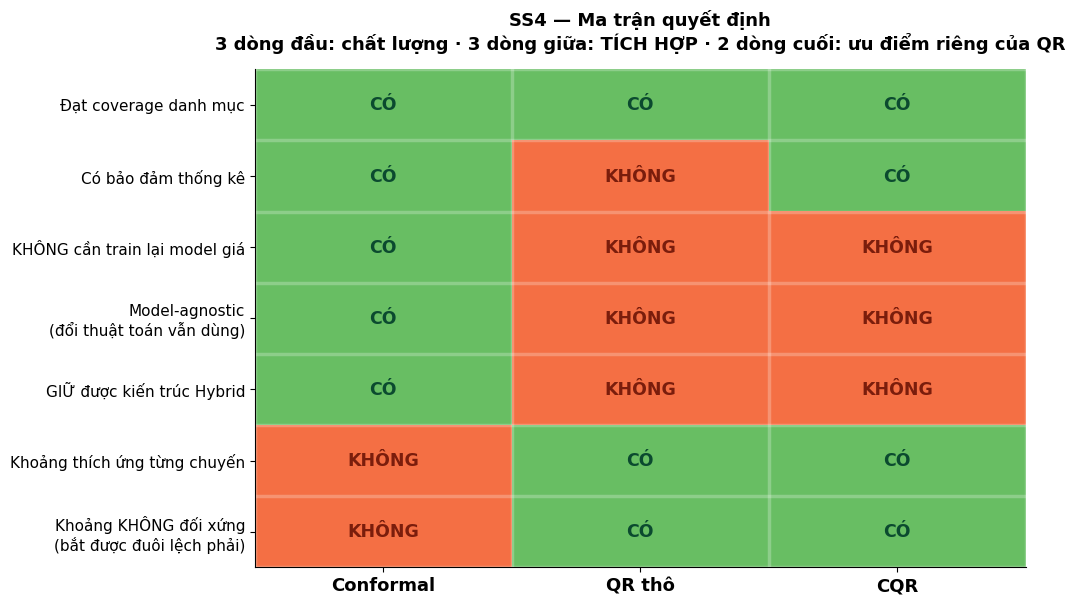

Tong so tieu chi dat duoc:
  Conformal    5/7
  QR thô       3/7
  CQR          4/7


In [32]:
# ═════════ HINH SS4 — ma tran quyet dinh ═════════
TIEU_CHI = ["Đạt coverage danh mục", "Có bảo đảm thống kê",
            "KHÔNG cần train lại model giá", "Model-agnostic\n(đổi thuật toán vẫn dùng)",
            "GIỮ được kiến trúc Hybrid", "Khoảng thích ứng từng chuyến",
            "Khoảng KHÔNG đối xứng\n(bắt được đuôi lệch phải)"]
DIEM = np.array([
    [1, 1, 1],      # dat coverage
    [1, 0, 1],      # bao dam
    [1, 0, 0],      # khong can train lai
    [1, 0, 0],      # model-agnostic
    [1, 0, 0],      # giu Hybrid
    [0, 1, 1],      # thich ung
    [0, 1, 1],      # khong doi xung
])

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.imshow(DIEM, cmap="RdYlGn", vmin=-.35, vmax=1.35, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(ngan, fontsize=13, fontweight="bold")
ax.set_yticks(range(len(TIEU_CHI))); ax.set_yticklabels(TIEU_CHI, fontsize=11)
for r in range(DIEM.shape[0]):
    for cc in range(DIEM.shape[1]):
        ax.text(cc, r, "CÓ" if DIEM[r, cc] else "KHÔNG", ha="center", va="center",
                fontsize=12.5, fontweight="bold",
                color="#0B4A2F" if DIEM[r, cc] else "#7A1D0C")
ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(TIEU_CHI), 1), minor=True)
ax.grid(which="minor", color="white", lw=2.5); ax.tick_params(which="minor", length=0)
ax.grid(which="major", alpha=0)
ax.set_title("SS4 — Ma trận quyết định\n3 dòng đầu: chất lượng · 3 dòng giữa: TÍCH HỢP · "
             "2 dòng cuối: ưu điểm riêng của QR",
             fontweight="bold", fontsize=13, pad=14)
plt.tight_layout(); plt.savefig(HINH / "SS4_ma_tran_quyet_dinh.png"); plt.show()

tong = DIEM.sum(axis=0)
print("Tong so tieu chi dat duoc:")
for ten, s in zip(ngan, tong):
    print(f"  {ten:12s} {s}/{len(TIEU_CHI)}")

## 5. Kết luận

In [33]:
# Tinh lai tai cho de khong phu thuoc bien o cell truoc
cov_ds = [KQ[k]["cov"] for k in PP]
rong_ds = [KQ[k]["rong"] for k in PP]

print("╔" + "═"*72 + "╗")
print("║" + " CAU PHAN (iii) — KET LUAN ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print(f"  {'':26s} {'Coverage':>10s} {'Do rong TB':>13s} {'Cong bang':>11s}")
print("  " + "-"*64)
for ten in PP:
    r = KQ[ten]
    print(f"  {ten:26s} {r['cov']:>9.2%} {r['rong']:>12,.0f}d {r['lech_dk']:>10.2f}")
print()
print("  XET THUAN THONG KE:  ca 3 tuong duong")
print(f"     coverage chenh {(max(cov_ds)-min(cov_ds))*100:.2f} diem  |  "
      f"do rong chenh {(max(rong_ds)/min(rong_ds)-1)*100:.1f}%")
print()
print("  XET KHA NANG TICH HOP:  Conformal thang ro")
print("     · KHONG can train lai model gia — boc quanh model co san")
print("     · Model-agnostic — doi thuat toan van dung duoc")
print("     · GIU nguyen kien truc Hybrid cua muc (ii)")
print()
print("─"*74)
print("  => CHON: Conformal chuan hoa lam MAC DINH")
print("     CQR lam phuong an du phong khi can khoang thich ung / khong doi xung")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                       CAU PHAN (iii) — KET LUAN                        ║
╚════════════════════════════════════════════════════════════════════════╝

                               Coverage    Do rong TB   Cong bang
  ----------------------------------------------------------------
  A. Conformal chuẩn hoá        89.55%       72,630d       2.00
  B. QR thô                     89.09%       75,783d       2.36
  C. CQR                        89.54%       76,449d       1.91

  XET THUAN THONG KE:  ca 3 tuong duong
     coverage chenh 0.46 diem  |  do rong chenh 5.3%

  XET KHA NANG TICH HOP:  Conformal thang ro
     · KHONG can train lai model gia — boc quanh model co san
     · Model-agnostic — doi thuat toan van dung duoc
     · GIU nguyen kien truc Hybrid cua muc (ii)

──────────────────────────────────────────────────────────────────────────
  => CHON: Conformal chuan hoa lam MAC DINH
     CQR lam phuong an du 